# Fraud and Anomaly Detection with Deep Learning


- use the **IEEE-CIS Fraud Detection** dataset as the primary dataset,
- create **aggregate** and **domain-specific** features,
- use a **chronological split** based on `TransactionDT`,
- compare a classical model trained on **raw features only** vs **raw + engineered features**.

The comments below are written so they can be reused in the final report.

## 0. loading Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
DATA_DIR = Path("ieee-fraud-detection")
TRAIN_TRANSACTION_PATH = DATA_DIR / "train_transaction.csv"
TRAIN_IDENTITY_PATH = DATA_DIR / "train_identity.csv"


## 1. Load and merge the primary dataset

The IEEE-CIS data is split into `train_transaction` and `train_identity`. We merge them by `TransactionID` so that transaction-level variables and identity/device variables are available in the same training table.

For this assignment, the split must be **time-based** instead of random. We therefore sort by `TransactionDT` and use the first 80% of records for training and the last 20% for testing. This reduces temporal leakage and better mimics real deployment.

In [2]:
train_transaction = pd.read_csv("ieee-fraud-detection/train_transaction.csv")
train_identity = pd.read_csv("ieee-fraud-detection/train_identity.csv")

df = train_transaction.merge(train_identity, how="left", on="TransactionID")
df = df.sort_values("TransactionDT").reset_index(drop=True)

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print(f"Full dataset shape: {df.shape}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Fraud rate in full data: {df['isFraud'].mean():.4%}")
print(f"Fraud rate in train data: {train_df['isFraud'].mean():.4%}")
print(f"Fraud rate in test data: {test_df['isFraud'].mean():.4%}")
print()
print("Train time range:")
print(train_df['TransactionDT'].min(), "->", train_df['TransactionDT'].max())
print("Test time range:")
print(test_df['TransactionDT'].min(), "->", test_df['TransactionDT'].max())


Full dataset shape: (590540, 434)
Train shape: (472432, 434)
Test shape: (118108, 434)
Fraud rate in full data: 3.4990%
Fraud rate in train data: 3.5135%
Fraud rate in test data: 3.4409%

Train time range:
86400 -> 12192842
Test time range:
12192900 -> 15811131


## 2. Feature engineering strategy

- **Time-based features**: hour of day, day index, weekday proxy, and whether the transaction occurs at night.
- **Amount pattern features**: log amount, cents pattern, rounded amount indicator, and amount deviation from user/card history.
- **Domain-specific email features**: purchaser/recipient email match, same provider flag, and reduced domain categories.
- **Aggregate user/card features**: counts, mean/std/max transaction amount for a pseudo-user identifier and for card/address groups.
- **Sequential behavior features**: time since last transaction for the same pseudo-user and same card.

To approximate a customer identity, we create a few entity keys from the available card, address, and email fields. 

Important leakage note:
- all aggregate mappings are learned from the **training split only** and then applied to train/test,
- `time_since_last_*` is computed using only historical transactions available before the current observation.

In [3]:
def simplify_email_domain(series):

    series = series.fillna("missing").astype(str).str.lower()
    provider = series.str.split(".").str[0]
    suffix = series.str.split(".").str[-1]
    return provider, suffix


def build_entity_keys(frame):
    frame = frame.copy()
    frame["uid"] = (
        frame["card1"].astype(str) + "_" +
        frame["card2"].astype(str) + "_" +
        frame["card3"].astype(str) + "_" +
        frame["card5"].astype(str) + "_" +
        frame["addr1"].astype(str) + "_" +
        frame["P_emaildomain"].fillna("missing").astype(str)
    )
    frame["card_addr"] = (
        frame["card1"].astype(str) + "_" +
        frame["addr1"].astype(str)
    )
    return frame


def add_time_features(frame):
    frame = frame.copy()
    seconds_in_day = 24 * 60 * 60
    frame["transaction_hour"] = (frame["TransactionDT"] // 3600) % 24
    frame["transaction_day"] = frame["TransactionDT"] // seconds_in_day
    frame["transaction_weekday_proxy"] = frame["transaction_day"] % 7
    frame["is_night_transaction"] = frame["transaction_hour"].isin([0, 1, 2, 3, 4, 5]).astype(int)
    return frame


def add_amount_features(frame):
    frame = frame.copy()
    # log-transform the amount to reduce skewness
    frame["TransactionAmt_log1p"] = np.log1p(frame["TransactionAmt"])
    cents = ((frame["TransactionAmt"].fillna(0) * 100).round() % 100).astype("float32")
    # Is the following operation needed?
    frame["amount_cents"] = cents
    frame["is_rounded_amount"] = (cents == 0).astype(int)
    frame["amount_decimal_pattern"] = (cents.isin([0, 50, 95, 99])).astype(int)
    return frame


def add_email_features(frame):
    frame = frame.copy()
    p_provider, p_suffix = simplify_email_domain(frame["P_emaildomain"])
    r_provider, r_suffix = simplify_email_domain(frame["R_emaildomain"])

    frame["P_email_provider"] = p_provider
    frame["R_email_provider"] = r_provider
    frame["P_email_suffix"] = p_suffix
    frame["R_email_suffix"] = r_suffix
    frame["email_domain_match"] = (
        frame["P_emaildomain"].fillna("missing") == frame["R_emaildomain"].fillna("missing")
    ).astype(int)
    frame["email_provider_match"] = (p_provider == r_provider).astype(int)
    return frame

# user's transaction frequency pattern
def add_history_gap_features(train_frame, test_frame, entity_col, prefix):
    train_frame = train_frame.copy()
    test_frame = test_frame.copy()

    train_frame[f"{prefix}_time_since_last_txn"] = (
        train_frame.groupby(entity_col)["TransactionDT"].diff().fillna(-1)
    )

    last_seen_time = train_frame.groupby(entity_col)["TransactionDT"].max()
    test_frame[f"{prefix}_time_since_last_txn"] = (
        test_frame["TransactionDT"] - test_frame[entity_col].map(last_seen_time)
    ).fillna(-1)

    return train_frame, test_frame

# user's transaction amount pattern
def add_aggregate_features(train_frame, test_frame):
    train_frame = train_frame.copy()
    test_frame = test_frame.copy()

    group_specs = {
        "uid": "uid",
        "card1": "card1",
        "card_addr": "card_addr",
    }

    for prefix, group_col in group_specs.items():
        stats = train_frame.groupby(group_col)["TransactionAmt"].agg(["count", "mean", "std", "max", "median"])
        stats.columns = [f"{prefix}_amt_{col}" for col in stats.columns]

        train_frame = train_frame.merge(stats, how="left", left_on=group_col, right_index=True)
        test_frame = test_frame.merge(stats, how="left", left_on=group_col, right_index=True)

        for stat_col in ["mean", "std", "max", "median"]:
            col_name = f"{prefix}_amt_{stat_col}"
            ratio_name = f"TransactionAmt_to_{prefix}_{stat_col}"
            train_frame[ratio_name] = train_frame["TransactionAmt"] / train_frame[col_name].replace(0, np.nan)
            test_frame[ratio_name] = test_frame["TransactionAmt"] / test_frame[col_name].replace(0, np.nan)

    return train_frame, test_frame


def engineer_features(train_frame, test_frame):
    train_frame = build_entity_keys(train_frame)
    test_frame = build_entity_keys(test_frame)

    for fn in [add_time_features, add_amount_features, add_email_features]:
        train_frame = fn(train_frame)
        test_frame = fn(test_frame)

    train_frame, test_frame = add_history_gap_features(train_frame, test_frame, entity_col="uid", prefix="uid")
    train_frame, test_frame = add_history_gap_features(train_frame, test_frame, entity_col="card1", prefix="card1")
    train_frame, test_frame = add_aggregate_features(train_frame, test_frame)

    engineered_columns = [
        "uid", "card_addr",
        "transaction_hour", "transaction_day", "transaction_weekday_proxy", "is_night_transaction",
        "TransactionAmt_log1p", "amount_cents", "is_rounded_amount", "amount_decimal_pattern",
        "P_email_provider", "R_email_provider", "P_email_suffix", "R_email_suffix",
        "email_domain_match", "email_provider_match",
        "uid_time_since_last_txn", "card1_time_since_last_txn",
        "uid_amt_count", "uid_amt_mean", "uid_amt_std", "uid_amt_max", "uid_amt_median",
        "card1_amt_count", "card1_amt_mean", "card1_amt_std", "card1_amt_max", "card1_amt_median",
        "card_addr_amt_count", "card_addr_amt_mean", "card_addr_amt_std", "card_addr_amt_max", "card_addr_amt_median",
        "TransactionAmt_to_uid_mean", "TransactionAmt_to_uid_std", "TransactionAmt_to_uid_max", "TransactionAmt_to_uid_median",
        "TransactionAmt_to_card1_mean", "TransactionAmt_to_card1_std", "TransactionAmt_to_card1_max", "TransactionAmt_to_card1_median",
        "TransactionAmt_to_card_addr_mean", "TransactionAmt_to_card_addr_std", "TransactionAmt_to_card_addr_max", "TransactionAmt_to_card_addr_median",
    ]

    return train_frame, test_frame, engineered_columns


In [4]:
train_fe, test_fe, engineered_columns = engineer_features(train_df, test_df)

print(f"Number of engineered features created: {len(engineered_columns)}")
display(pd.DataFrame({"engineered_feature": engineered_columns}).head(20))

feature_preview_cols = [
    "TransactionDT", "TransactionAmt", "uid", "transaction_hour", "is_night_transaction",
    "TransactionAmt_log1p", "email_provider_match", "uid_time_since_last_txn",
    "uid_amt_mean", "TransactionAmt_to_uid_mean"
]
display(train_fe[feature_preview_cols].head())


Number of engineered features created: 45


,engineered_feature
0,uid
1,card_addr
2,transaction_hour
3,transaction_day
4,transaction_weekday_proxy
5,is_night_transaction
6,TransactionAmt_log1p
7,amount_cents
8,is_rounded_amount
9,amount_decimal_pattern


,TransactionDT,TransactionAmt,uid,transaction_hour,is_night_transaction,TransactionAmt_log1p,email_provider_match,uid_time_since_last_txn,uid_amt_mean,TransactionAmt_to_uid_mean
0,86400,68.5,13926_nan_150.0_142.0_315.0_missing,0,1,4.241327,1,-1.0,68.500000,1.000000
1,86401,29.0,2755_404.0_150.0_102.0_325.0_gmail.com,0,1,3.401197,0,-1.0,853.542727,0.033976
2,86469,59.0,4663_490.0_150.0_166.0_330.0_outlook.com,0,1,4.094345,0,-1.0,70.000000,0.842857
3,86499,50.0,18132_567.0_150.0_117.0_476.0_yahoo.com,0,1,3.931826,0,-1.0,72.927273,0.685615
4,86506,50.0,4497_514.0_150.0_102.0_420.0_gmail.com,0,1,3.931826,0,-1.0,50.000000,1.000000


## 3. Exploratory data analysis

Before modeling, we visualize the core structure of the IEEE-CIS dataset. 

- whether fraud is extremely imbalanced,
- whether fraud rate changes over time,
- whether transaction amount behaves differently for fraud vs normal transactions,
- whether certain product/device/email groups concentrate more fraud,
- whether missingness itself may contain useful signal,
- whether engineered behavioral features separate fraud from normal cases.

These plots help justify later choices such as AUPRC-focused evaluation, chronological splitting, class weighting, and behavior-based feature engineering.

In [8]:
import matplotlib.ticker as mtick

plt.style.use("seaborn-v0_8-whitegrid")
PLOT_COLORS = {
    "normal": "#2A9D8F",
    "fraud": "#E76F51",
    "accent": "#264653",
    "muted": "#E9C46A",
}

def add_value_labels(ax, fmt="{:.2f}", suffix=""):
    for patch in ax.patches:
        height = patch.get_height()
        if np.isfinite(height):
            ax.annotate(
                fmt.format(height) + suffix,
                (patch.get_x() + patch.get_width() / 2, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 3),
                textcoords="offset points",
            )


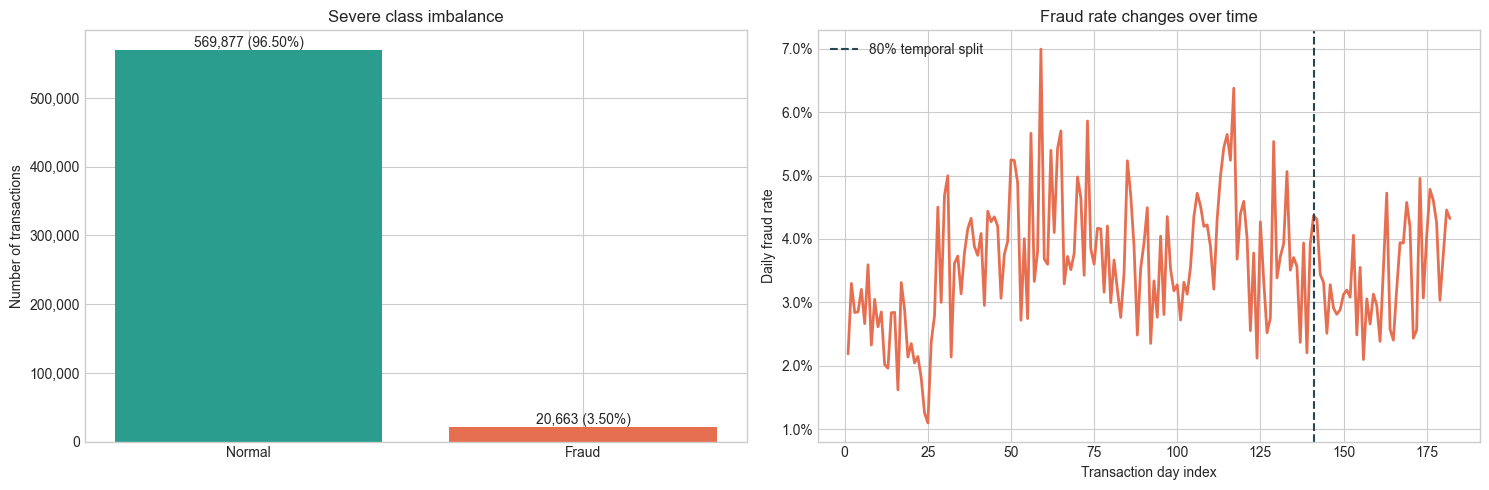

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

class_counts = df["isFraud"].value_counts().sort_index()
class_labels = ["Normal", "Fraud"]
axes[0].bar(class_labels, class_counts.values, color=[PLOT_COLORS["normal"], PLOT_COLORS["fraud"]])
axes[0].set_title("Severe class imbalance")
axes[0].set_ylabel("Number of transactions")
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

for idx, count in enumerate(class_counts.values):
    pct = count / len(df)
    axes[0].text(idx, count, f"{count:,.0f} ({pct:.2%})", ha="center", va="bottom", fontsize=10)

fraud_by_day = (
    df.assign(transaction_day=df["TransactionDT"] // (24 * 60 * 60))
      .groupby("transaction_day")
      .agg(fraud_rate=("isFraud", "mean"), n_txn=("isFraud", "size"))
      .reset_index()
)
axes[1].plot(fraud_by_day["transaction_day"], fraud_by_day["fraud_rate"], color=PLOT_COLORS["fraud"], linewidth=2)
axes[1].axvline(train_df["TransactionDT"].max() // (24 * 60 * 60), color=PLOT_COLORS["accent"], linestyle="--", label="80% temporal split")
axes[1].set_title("Fraud rate changes over time")
axes[1].set_xlabel("Transaction day index")
axes[1].set_ylabel("Daily fraud rate")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].legend()

plt.tight_layout()
plt.show()


Fraud is rare and temporally non-stationary, so accuracy is misleading and random splits can overestimate performance.

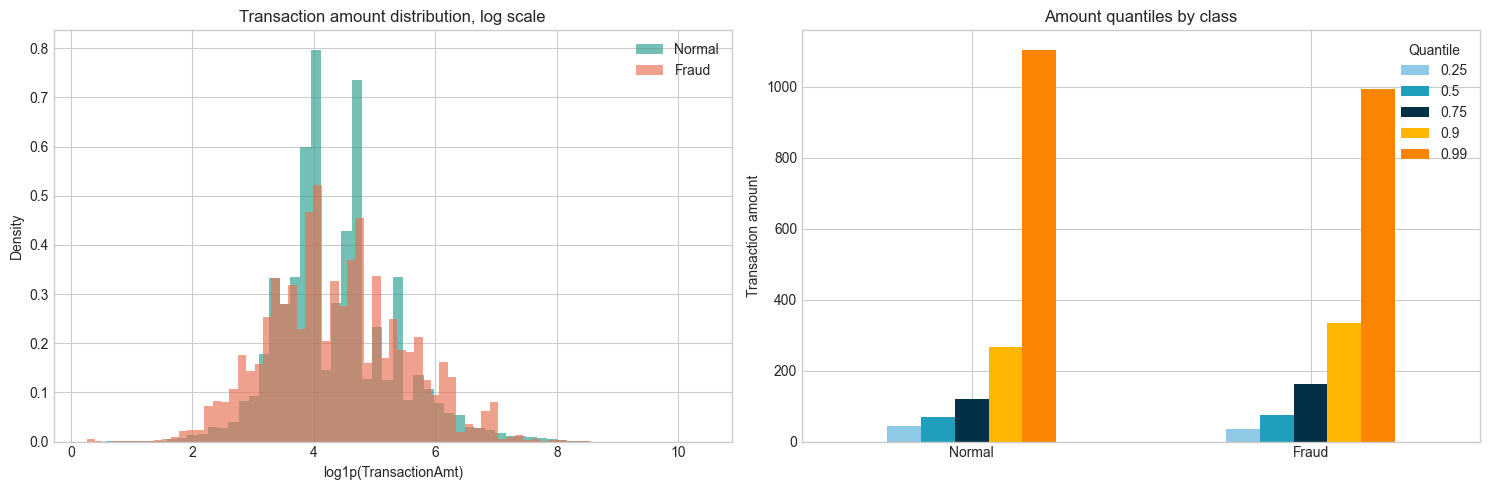

,0.25,0.50,0.75,0.90,0.99
isFraud,,,,,
Normal,43.970,68.5,120.0,267.112,1104.0
Fraud,35.044,75.0,161.0,335.000,994.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_df = df[["isFraud", "TransactionAmt"]].copy()
plot_df["log_amount"] = np.log1p(plot_df["TransactionAmt"])

axes[0].hist(
    plot_df.loc[plot_df["isFraud"] == 0, "log_amount"],
    bins=60,
    alpha=0.65,
    density=True,
    label="Normal",
    color=PLOT_COLORS["normal"],
)
axes[0].hist(
    plot_df.loc[plot_df["isFraud"] == 1, "log_amount"],
    bins=60,
    alpha=0.65,
    density=True,
    label="Fraud",
    color=PLOT_COLORS["fraud"],
)
axes[0].set_title("Transaction amount distribution, log scale")
axes[0].set_xlabel("log1p(TransactionAmt)")
axes[0].set_ylabel("Density")
axes[0].legend()

amount_summary = (
    df.groupby("isFraud")["TransactionAmt"]
      .quantile([0.25, 0.5, 0.75, 0.9, 0.99])
      .unstack()
      .rename(index={0: "Normal", 1: "Fraud"})
)
amount_summary.plot(kind="bar", ax=axes[1], color=["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"])
axes[1].set_title("Amount quantiles by class")
axes[1].set_xlabel("")
axes[1].set_ylabel("Transaction amount")
axes[1].legend(title="Quantile")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

display(amount_summary)


Modeling implication: amount should be transformed and compared against user/card history instead of used only as a raw numeric feature.

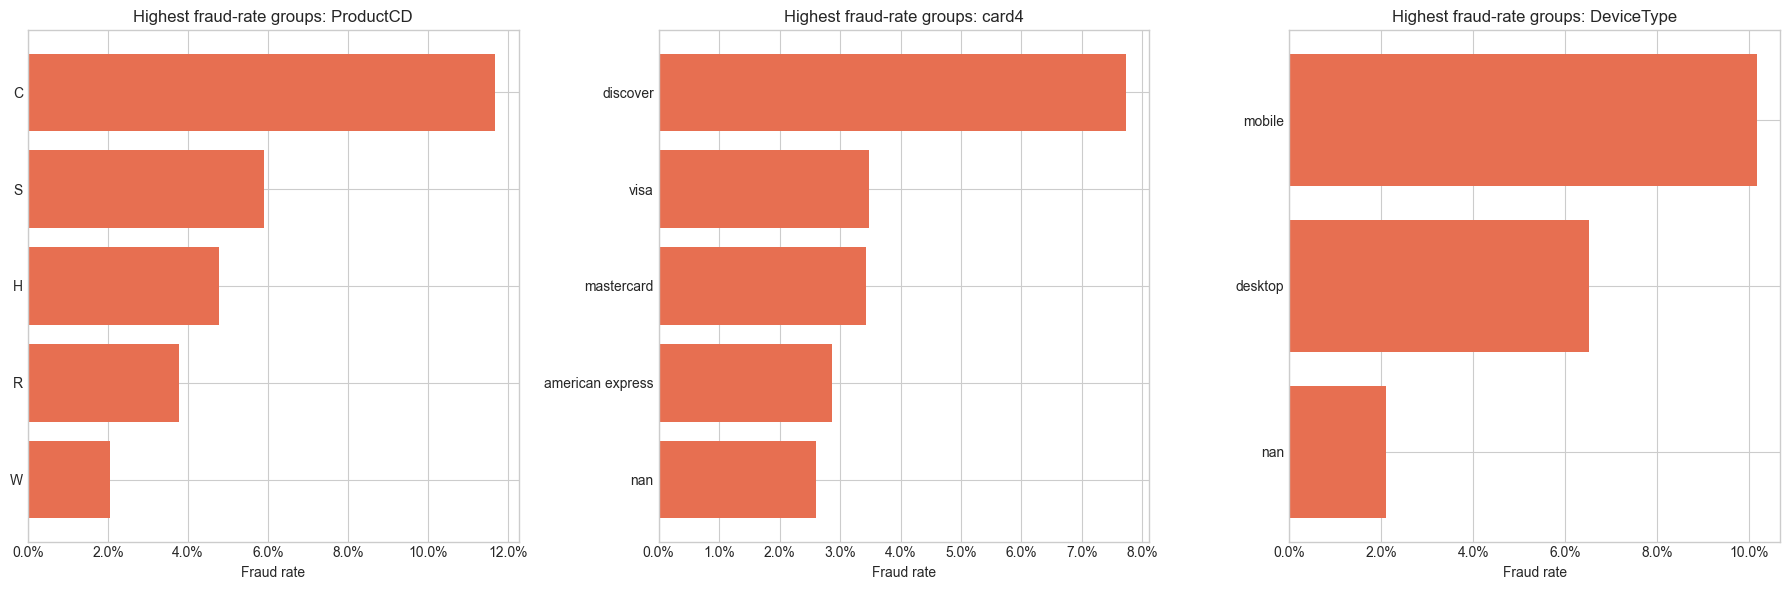

ProductCD groups:


,ProductCD,fraud_rate,n_txn
0,C,0.116873,68519
1,S,0.058996,11628
2,H,0.047662,33024
3,R,0.037826,37699
4,W,0.020399,439670


card4 groups:


,card4,fraud_rate,n_txn
0,discover,0.077282,6651
1,visa,0.034756,384767
2,mastercard,0.034331,189217
3,american express,0.028698,8328
4,nan,0.025999,1577


DeviceType groups:


,DeviceType,fraud_rate,n_txn
0,mobile,0.101662,55645
1,desktop,0.065215,85165
2,nan,0.021017,449730


In [11]:
def plot_group_fraud_rate(frame, col, ax, top_n=12, min_count=300):
    group_stats = (
        frame.groupby(col, dropna=False)
             .agg(fraud_rate=("isFraud", "mean"), n_txn=("isFraud", "size"))
             .query("n_txn >= @min_count")
             .sort_values("fraud_rate", ascending=False)
             .head(top_n)
             .reset_index()
    )
    group_stats[col] = group_stats[col].astype(str)
    ax.barh(group_stats[col][::-1], group_stats["fraud_rate"][::-1], color=PLOT_COLORS["fraud"])
    ax.set_title(f"Highest fraud-rate groups: {col}")
    ax.set_xlabel("Fraud rate")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("")
    return group_stats

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
product_stats = plot_group_fraud_rate(df, "ProductCD", axes[0], top_n=8, min_count=100)
card4_stats = plot_group_fraud_rate(df, "card4", axes[1], top_n=8, min_count=100)
device_stats = plot_group_fraud_rate(df, "DeviceType", axes[2], top_n=8, min_count=100)
plt.tight_layout()
plt.show()

print("ProductCD groups:")
display(product_stats)
print("card4 groups:")
display(card4_stats)
print("DeviceType groups:")
display(device_stats)


Modeling implication: categorical variables are useful risk segments, so tree models or categorical encoders should preserve them rather than dropping them.

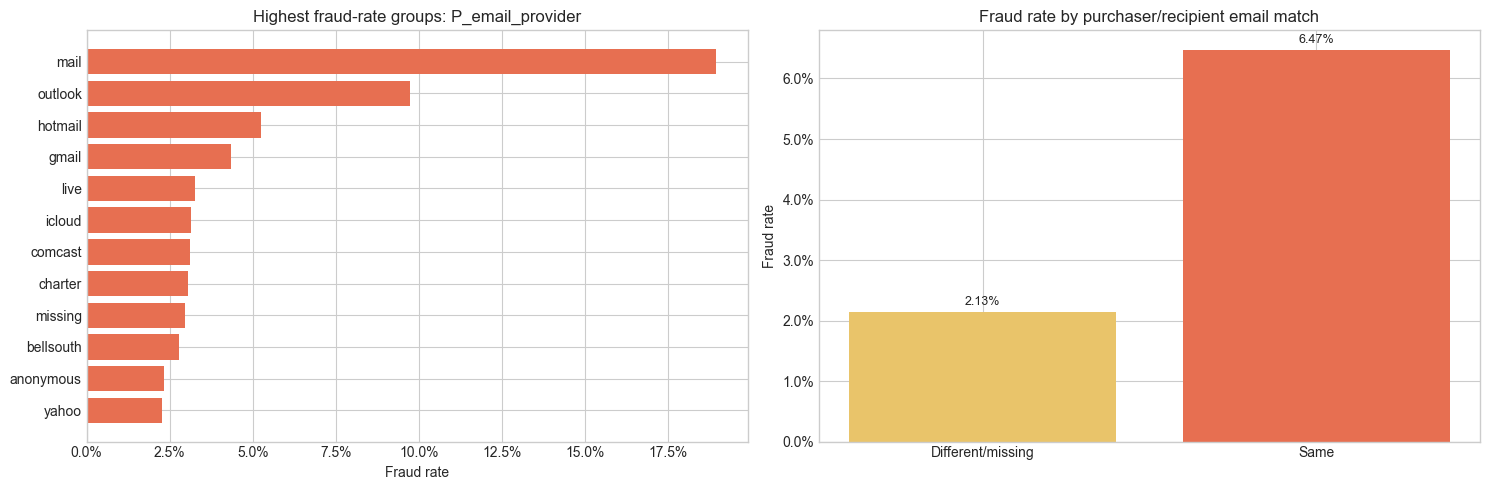

In [12]:
email_df = df.copy()
email_df["P_email_provider"] = email_df["P_emaildomain"].fillna("missing").astype(str).str.lower().str.split(".").str[0]
email_df["R_email_provider"] = email_df["R_emaildomain"].fillna("missing").astype(str).str.lower().str.split(".").str[0]
email_df["email_domain_match"] = (
    email_df["P_emaildomain"].fillna("missing") == email_df["R_emaildomain"].fillna("missing")
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_group_fraud_rate(email_df, "P_email_provider", axes[0], top_n=12, min_count=500)
email_match_stats = email_df.groupby("email_domain_match")["isFraud"].mean().rename(index={False: "Different/missing", True: "Same"})
axes[1].bar(email_match_stats.index.astype(str), email_match_stats.values, color=[PLOT_COLORS["muted"], PLOT_COLORS["fraud"]])
axes[1].set_title("Fraud rate by purchaser/recipient email match")
axes[1].set_ylabel("Fraud rate")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
add_value_labels(axes[1], fmt="{:.2%}")

plt.tight_layout()
plt.show()


Modeling implication: email-domain features can capture domain-specific and purchaser-recipient consistency signals.

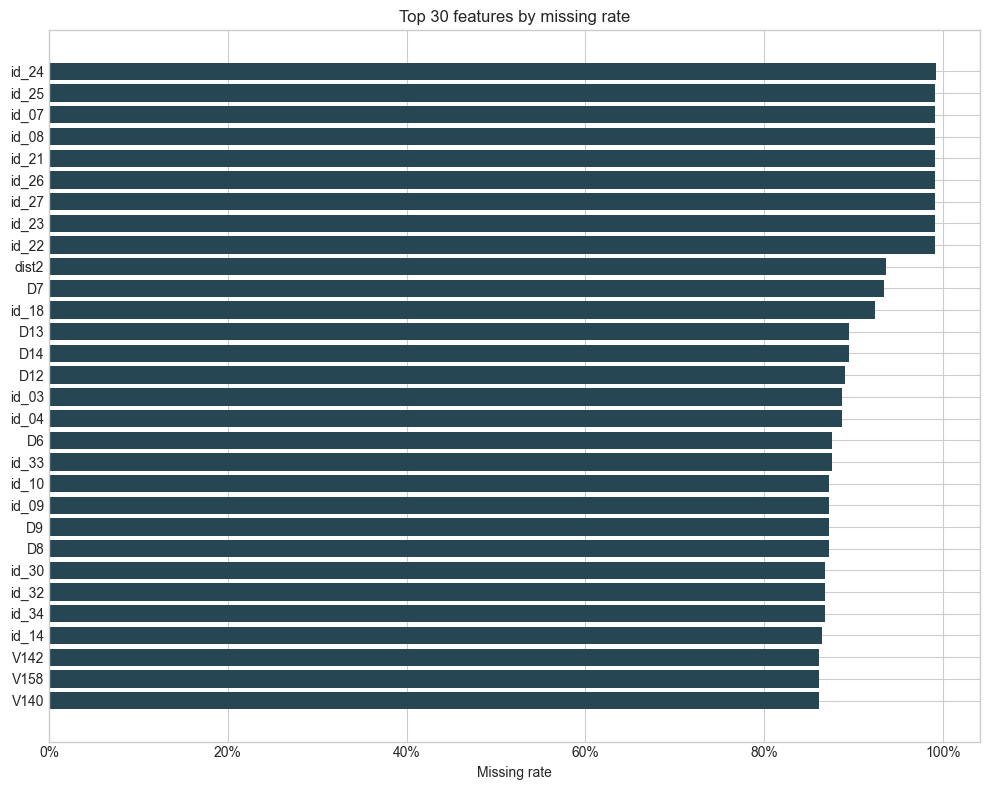

,feature,missing_rate
0,id_24,0.991962
1,id_25,0.991310
2,id_07,0.991271
3,id_08,0.991271
4,id_21,0.991264
5,id_26,0.991257
6,id_27,0.991247
7,id_23,0.991247
8,id_22,0.991247
9,dist2,0.936284


Modeling implication: missingness is very common in identity/device variables, so imputation and missing indicators may matter. Extremely sparse columns may need to be removed or handled carefully.


In [13]:
missing_summary = (
    df.isna().mean()
      .sort_values(ascending=False)
      .head(30)
      .rename("missing_rate")
      .reset_index()
      .rename(columns={"index": "feature"})
)

plt.figure(figsize=(10, 8))
plt.barh(missing_summary["feature"][::-1], missing_summary["missing_rate"][::-1], color=PLOT_COLORS["accent"])
plt.title("Top 30 features by missing rate")
plt.xlabel("Missing rate")
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.ylabel("")
plt.tight_layout()
plt.show()

display(missing_summary)
print("Modeling implication: missingness is very common in identity/device variables, so imputation and missing indicators may matter. Extremely sparse columns may need to be removed or handled carefully.")


Missingness is very common in identity/device variables, so imputation and missing indicators may matter. Extremely sparse columns may need to be removed or handled carefully.

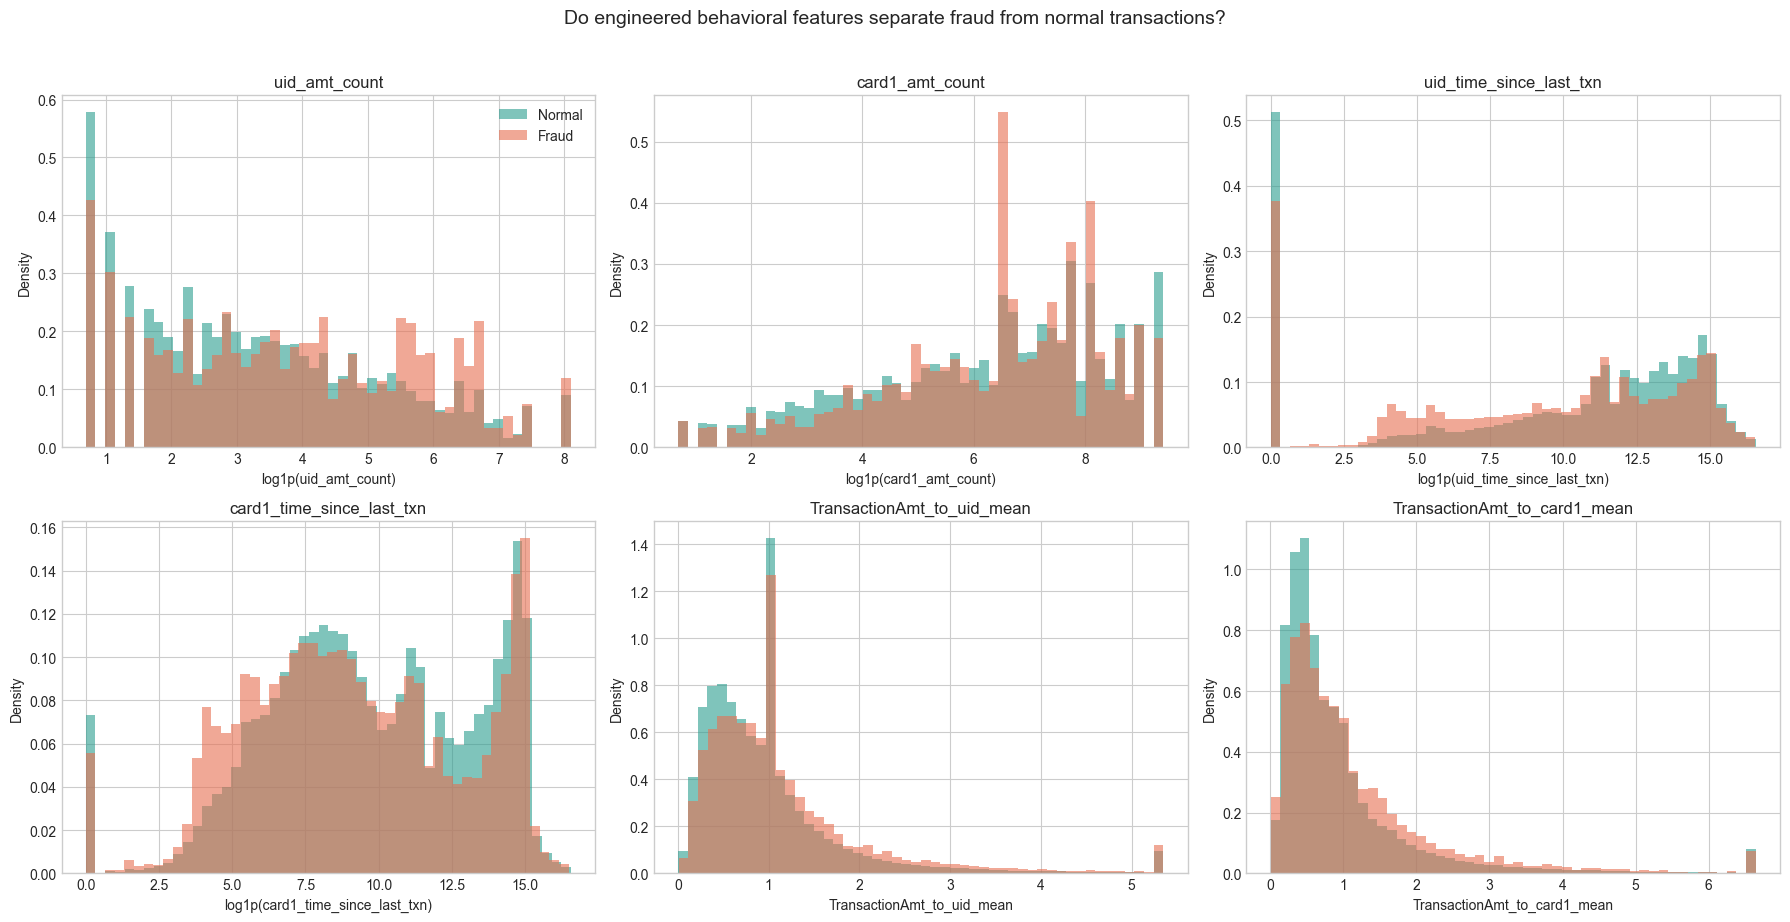

In [14]:
# These plots use the engineered train/test frames created above.
engineered_signal_df = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)

signal_features = [
    "uid_amt_count",
    "card1_amt_count",
    "uid_time_since_last_txn",
    "card1_time_since_last_txn",
    "TransactionAmt_to_uid_mean",
    "TransactionAmt_to_card1_mean",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for ax, col in zip(axes, signal_features):
    temp = engineered_signal_df[["isFraud", col]].copy()
    temp[col] = temp[col].replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna(subset=[col])
    if "time_since" in col or "count" in col:
        temp[col] = np.log1p(temp[col].clip(lower=0))
        xlabel = f"log1p({col})"
    else:
        upper = temp[col].quantile(0.99)
        temp[col] = temp[col].clip(upper=upper)
        xlabel = col

    ax.hist(temp.loc[temp["isFraud"] == 0, col], bins=50, density=True, alpha=0.6, color=PLOT_COLORS["normal"], label="Normal")
    ax.hist(temp.loc[temp["isFraud"] == 1, col], bins=50, density=True, alpha=0.6, color=PLOT_COLORS["fraud"], label="Fraud")
    ax.set_title(col)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")

axes[0].legend()
plt.suptitle("Do engineered behavioral features separate fraud from normal transactions?", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


If these distributions differ, the engineered features provide behavior-based signals that raw transaction columns may not capture directly.

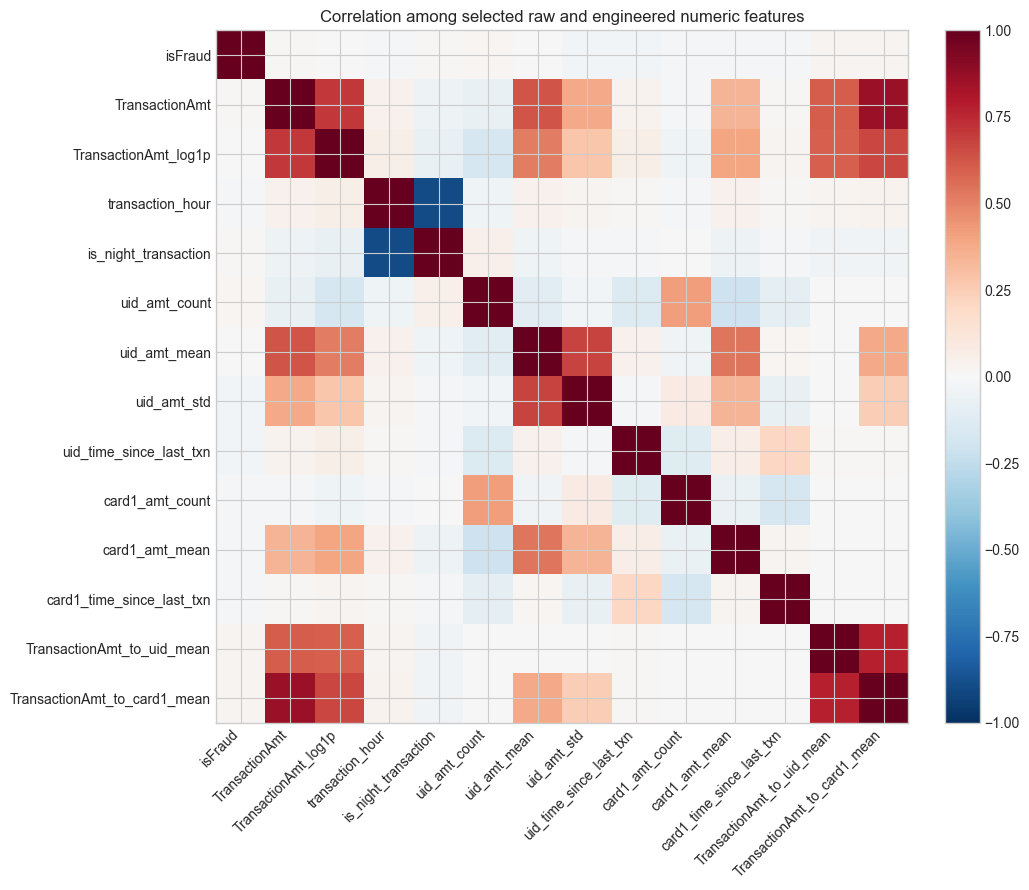

,correlation_with_isFraud
uid_time_since_last_txn,-0.025476
uid_amt_std,-0.025173
TransactionAmt_to_uid_mean,0.024934
TransactionAmt_to_card1_mean,0.024544
uid_amt_count,0.021138
card1_amt_mean,-0.020044
card1_time_since_last_txn,-0.015646
transaction_hour,-0.012387
TransactionAmt,0.011759
card1_amt_count,-0.011476


In [15]:
numeric_focus_cols = [
    "isFraud", "TransactionAmt", "TransactionAmt_log1p", "transaction_hour", "is_night_transaction",
    "uid_amt_count", "uid_amt_mean", "uid_amt_std", "uid_time_since_last_txn",
    "card1_amt_count", "card1_amt_mean", "card1_time_since_last_txn",
    "TransactionAmt_to_uid_mean", "TransactionAmt_to_card1_mean",
]

corr_frame = train_fe[numeric_focus_cols].replace([np.inf, -np.inf], np.nan).copy()
corr = corr_frame.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation among selected raw and engineered numeric features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fraud_corr = corr["isFraud"].drop("isFraud").sort_values(key=lambda s: s.abs(), ascending=False)
display(fraud_corr.to_frame("correlation_with_isFraud"))

Correlation is only a linear signal, but it gives a quick sanity check for which engineered features may carry useful information

In general, we expect the following modeling priorities:

- **Use AUPRC as the primary metric**, because the class balance plot shows fraud is rare.
- **Keep the chronological split**, because daily fraud rate can shift over time.
- **Use class weighting or imbalance-aware losses**, because the model otherwise may focus too much on normal transactions.
- **Preserve categorical risk segments**, because product, card, device, and email groups can have different fraud rates.
- **Use amount transformations and behavior ratios**, because raw amount alone may not capture whether a transaction is unusual for that user/card.
- **Handle missingness deliberately**, because identity/device columns have structured missing values that may be informative.


## 4. Compare raw features vs engineered features

- We drop `TransactionID` and the target `isFraud` from the predictor list.
- We also remove columns that are almost empty or constant in the training split.
- If `lightgbm` is available, we use it as the classical baseline because gradient boosting is explicitly recommended in the assignment.
- If not, the notebook falls back to `HistGradientBoostingClassifier` from scikit-learn.

The key comparison is:

- **Raw model**: original columns only.
- **Feature-engineered model**: original columns + engineered columns.


In [16]:
def select_base_features(train_frame, test_frame, missing_threshold=0.98):
    exclude_cols = {"isFraud", "TransactionID"}
    candidate_cols = [col for col in train_frame.columns if col not in exclude_cols]

    valid_cols = []
    for col in candidate_cols:
        if train_frame[col].isna().mean() > missing_threshold:
            continue
        if train_frame[col].nunique(dropna=False) <= 1:
            continue
        valid_cols.append(col)

    return valid_cols


def prepare_for_lightgbm(train_frame, test_frame, feature_cols):
    X_train = train_frame[feature_cols].copy()
    X_test = test_frame[feature_cols].copy()

    categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = [col for col in feature_cols if col not in categorical_cols]

    for col in numeric_cols:
        median_value = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_value)
        X_test[col] = X_test[col].fillna(median_value)

    for col in categorical_cols:
        X_train[col] = X_train[col].fillna("missing").astype("category")
        X_test[col] = X_test[col].fillna("missing").astype("category")

    return X_train, X_test, categorical_cols


def fit_and_score_model(train_frame, test_frame, feature_cols):
    y_train = train_frame["isFraud"]
    y_test = test_frame["isFraud"]

    try:
        import lightgbm as lgb

        X_train, X_test, categorical_cols = prepare_for_lightgbm(train_frame, test_frame, feature_cols)
        model = lgb.LGBMClassifier(
            objective="binary",
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=64,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_train, y_train, categorical_feature=categorical_cols)
        y_score = model.predict_proba(X_test)[:, 1]
        model_name = "LightGBM"

    except ImportError:
        X_train = train_frame[feature_cols].copy()
        X_test = test_frame[feature_cols].copy()

        categorical_cols = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
        numeric_cols = [col for col in feature_cols if col not in categorical_cols]

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", SimpleImputer(strategy="median"), numeric_cols),
                (
                    "cat",
                    Pipeline([
                        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                    ]),
                    categorical_cols,
                ),
            ],
        )

        model = Pipeline([
            ("preprocess", preprocessor),
            (
                "model",
                HistGradientBoostingClassifier(
                    max_depth=6,
                    learning_rate=0.05,
                    max_iter=250,
                    random_state=RANDOM_STATE,
                ),
            ),
        ])

        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        model.fit(X_train, y_train, model__sample_weight=sample_weight)
        y_score = model.predict_proba(X_test)[:, 1]
        model_name = "HistGradientBoostingClassifier"

    auprc = average_precision_score(y_test, y_score)
    roc_auc = roc_auc_score(y_test, y_score)

    return {
        "model": model_name,
        "auprc": auprc,
        "roc_auc": roc_auc,
        "y_true": y_test,
        "y_score": y_score,
    }


In [17]:
base_features = select_base_features(train_df, test_df)
engineered_only = [col for col in engineered_columns if col in train_fe.columns]
feature_engineered_features = base_features + [col for col in engineered_only if col not in base_features]

print(f"Number of usable raw features: {len(base_features)}")
print(f"Number of usable raw + engineered features: {len(feature_engineered_features)}")

raw_result = fit_and_score_model(train_df, test_df, base_features)
fe_result = fit_and_score_model(train_fe, test_fe, feature_engineered_features)

comparison_df = pd.DataFrame([
    {
        "setting": "Raw features only",
        "model": raw_result["model"],
        "AUPRC": raw_result["auprc"],
        "ROC_AUC": raw_result["roc_auc"],
    },
    {
        "setting": "Raw + engineered features",
        "model": fe_result["model"],
        "AUPRC": fe_result["auprc"],
        "ROC_AUC": fe_result["roc_auc"],
    },
])

comparison_df["AUPRC_lift"] = comparison_df["AUPRC"] - comparison_df.loc[0, "AUPRC"]
display(comparison_df)


Number of usable raw features: 423
Number of usable raw + engineered features: 468
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.150624 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33730
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 420
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] Fo

,setting,model,AUPRC,ROC_AUC,AUPRC_lift
0,Raw features only,LightGBM,0.534647,0.906576,0.0000
1,Raw + engineered features,LightGBM,0.583447,0.907419,0.0488


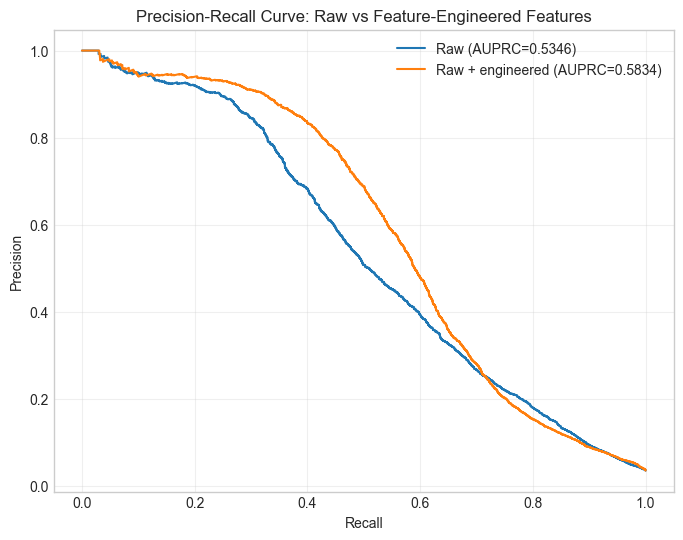

In [18]:
plt.figure(figsize=(8, 6))

for label, result in [("Raw", raw_result), ("Raw + engineered", fe_result)]:
    precision, recall, _ = precision_recall_curve(result["y_true"], result["y_score"])
    plt.plot(recall, precision, label=f"{label} (AUPRC={result['auprc']:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: Raw vs Feature-Engineered Features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 5. Classical Anomaly Detection Baselines

The assignment asks us to implement and compare **classical anomaly detection** methods.
All methods below are trained in **semi-supervised** mode: fit only on the normal-class
training samples, then scored on the full test set.

| Method | Paradigm | Key idea |
|---|---|---|
| Isolation Forest | Tree-based | Anomalies are isolated in fewer splits |
| Local Outlier Factor | Density-based | Anomalies live in low-density neighbourhoods |



In [19]:
# 5.1  Shared setup for classical models
# We reuse train_fe / test_fe and the existing RANDOM_STATE constant.
# Only numeric features are used (LOF / IF do not handle categoricals natively).
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

def select_numeric_features(train_frame, test_frame, missing_threshold=0.98):
    """Return numeric columns shared by both splits, below missing threshold."""
    num_cols = train_frame.select_dtypes(include=[np.number]).columns.tolist()
    exclude  = {"isFraud", "TransactionID", "TransactionDT"}
    return [
        c for c in num_cols
        if c not in exclude
        and train_frame[c].isna().mean() < missing_threshold
        and c in test_frame.columns
    ]

num_cols = select_numeric_features(train_fe, test_fe)
print(f"Numeric features for classical models: {len(num_cols)}")

y_train_cl = train_fe["isFraud"].values
y_test_cl  = test_fe["isFraud"].values

# Impute then scale (fit only on training normals — avoids leakage)
normal_mask = (y_train_cl == 0)

imputer = SimpleImputer(strategy="median")
imputer.fit(train_fe.loc[train_fe["isFraud"] == 0, num_cols])
X_train_imp = imputer.transform(train_fe[num_cols])
X_test_imp  = imputer.transform(test_fe[num_cols])

scaler = StandardScaler()
scaler.fit(X_train_imp[normal_mask])
X_train_sc   = scaler.transform(X_train_imp)
X_test_sc    = scaler.transform(X_test_imp)
X_train_norm = X_train_sc[normal_mask]   # normal-only subset for training

print(f"Normal train samples : {normal_mask.sum():,}")
print(f"Fraud  train samples : {(~normal_mask).sum():,}")
print(f"Test   samples       : {len(y_test_cl):,}")


Numeric features for classical models: 432
Normal train samples : 455,833
Fraud  train samples : 16,599
Test   samples       : 118,108


In [20]:
# 5.2  Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    contamination=float(y_train_cl.mean()),   # use true train fraud rate
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_train_norm)

# score_samples returns lower values for anomalies; negate so higher = more anomalous
iso_scores = -iso.score_samples(X_test_sc)
iso_auprc  = average_precision_score(y_test_cl, iso_scores)
iso_roc    = roc_auc_score(y_test_cl, iso_scores)
print(f"Isolation Forest  AUPRC={iso_auprc:.4f}  ROC-AUC={iso_roc:.4f}")


Isolation Forest  AUPRC=0.1221  ROC-AUC=0.7694


In [21]:
# 5.3  Local Outlier Factor  (novelty=True => fit on normals, predict on test)
# LOF is O(n^2) in memory; cap the training set size for practical runtime.
print("Training LOF (this may take 1–2 min) ...")
MAX_LOF = 30_000
rng = np.random.default_rng(RANDOM_STATE)
lof_idx = rng.choice(X_train_norm.shape[0],
                      min(MAX_LOF, X_train_norm.shape[0]),
                      replace=False)

lof = LocalOutlierFactor(
    n_neighbors=20,
    novelty=True,
    contamination=float(y_train_cl.mean()),
    n_jobs=-1,
)
lof.fit(X_train_norm[lof_idx])

lof_scores = -lof.decision_function(X_test_sc)   # higher = more anomalous
lof_auprc  = average_precision_score(y_test_cl, lof_scores)
lof_roc    = roc_auc_score(y_test_cl, lof_scores)
print(f"LOF               AUPRC={lof_auprc:.4f}  ROC-AUC={lof_roc:.4f}")


Training LOF (this may take 1–2 min) ...
LOF               AUPRC=0.0722  ROC-AUC=0.6814


In [22]:
# 5.4  Classical baselines summary table
classical_df = pd.DataFrame([
    {"Method": "Isolation Forest (semi-sup)", "AUPRC": iso_auprc, "ROC-AUC": iso_roc},
    {"Method": "LOF (semi-sup)",              "AUPRC": lof_auprc, "ROC-AUC": lof_roc},
    {"Method": "LightGBM – raw (supervised)",
     "AUPRC": raw_result["auprc"], "ROC-AUC": raw_result["roc_auc"]},
    {"Method": "LightGBM + FE (supervised)",
     "AUPRC": fe_result["auprc"],  "ROC-AUC": fe_result["roc_auc"]},
]).sort_values("AUPRC", ascending=False).reset_index(drop=True)

display(classical_df.round(4))
print("\nImplication: labelled data gives supervised models a large advantage over"
      " unsupervised methods. Among classical anomaly detectors, IF often outperforms"
      " LOF on tabular data because it scales better with feature count.")


,Method,AUPRC,ROC-AUC
0,LightGBM + FE (supervised),0.5834,0.9074
1,LightGBM – raw (supervised),0.5346,0.9066
2,Isolation Forest (semi-sup),0.1221,0.7694
3,LOF (semi-sup),0.0722,0.6814



Implication: labelled data gives supervised models a large advantage over unsupervised methods. Among classical anomaly detectors, IF often outperforms LOF on tabular data because it scales better with feature count.


## 6. Deep Learning

We implement three deep learning models required by the assignment:

| Model | Paradigm | Training data |
|---|---|---|
| **Variational Autoencoder (VAE)** | Semi-supervised | Normal-only |
| **Deep SVDD** | Semi-supervised | Normal-only |
| **Supervised MLP + Focal Loss** | Supervised | All labelled data |

The VAE uses reconstruction error as the anomaly score.
Deep SVDD minimises the distance of normal embeddings from a hypersphere centre.
The supervised MLP uses Focal Loss to handle class imbalance directly.

All models share the same imputed/scaled numeric feature matrix from Section 5.


In [ ]:
# 6.0  PyTorch imports and tensor setup
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def _t(arr, dtype=torch.float32):
    return torch.tensor(arr, dtype=dtype)

# Reuse X_train_sc / X_test_sc / X_train_norm built in Section 5
X_tr_t   = _t(X_train_sc)    # full training set (all classes)
X_te_t   = _t(X_test_sc)     # test set
y_tr_t   = _t(y_train_cl)    # labels for supervised training
X_norm_t = _t(X_train_norm)  # normal-only for unsupervised training

BATCH      = 1024
INPUT_DIM  = X_train_sc.shape[1]
all_dl     = DataLoader(TensorDataset(X_tr_t, y_tr_t),  batch_size=BATCH, shuffle=True)
norm_dl    = DataLoader(TensorDataset(X_norm_t),          batch_size=BATCH, shuffle=True)
print(f"Input dimension: {INPUT_DIM}")


Using device: cpu


In [ ]:
# 6.1  Variational Autoencoder (VAE)
# Trained on NORMAL-only samples. Anomaly score = mean reconstruction MSE
# averaged over k=10 latent samples (reduces variance from the stochastic encoder).

class VAE(nn.Module):
    def __init__(self, in_dim, hidden=256, latent=48, dropout=0.2):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),                    nn.ReLU(),
        )
        self.mu_fc     = nn.Linear(hidden // 2, latent)
        self.logvar_fc = nn.Linear(hidden // 2, latent)
        self.dec = nn.Sequential(
            nn.Linear(latent,      hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, hidden),      nn.ReLU(),
            nn.Linear(hidden,      in_dim),
        )

    def encode(self, x):
        h = self.enc(x)
        return self.mu_fc(h), self.logvar_fc(h)

    def reparametrize(self, mu, lv):
        return mu + torch.randn_like(mu) * (0.5 * lv).exp()

    def forward(self, x):
        mu, lv = self.encode(x)
        return self.dec(self.reparametrize(mu, lv)), mu, lv

    @torch.no_grad()
    def anomaly_score(self, X_tensor, k=10):
        """Mean per-sample MSE over k stochastic forward passes."""
        self.eval()
        dl  = DataLoader(TensorDataset(X_tensor), batch_size=2048, shuffle=False)
        out = []
        for (xb,) in dl:
            xb = xb.to(DEVICE)
            s  = torch.stack([
                F.mse_loss(self.dec(self.reparametrize(*self.encode(xb))),
                           xb, reduction="none").mean(1)
                for _ in range(k)
            ]).mean(0)
            out.append(s.cpu())
        return torch.cat(out).numpy()


def train_vae(model, loader, epochs=40, lr=5e-4, beta=0.5):
    model.to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(1, epochs + 1):
        model.train()
        total = 0.0
        for batch in loader:           # ← 改这里
            xb = batch[0].to(DEVICE)   # ← 改这里
            recon, mu, lv = model(xb)
            loss = (F.mse_loss(recon, xb)
                    + beta * (-0.5 * torch.mean(1 + lv - mu.pow(2) - lv.exp())))
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        sched.step()
        if ep % 10 == 0 or ep == 1:
            print(f"  VAE  ep {ep:3d}/{epochs}  loss={total / len(loader):.5f}")
    return model


print("Training VAE (normal-only) ...")
vae_model = VAE(INPUT_DIM)
vae_model = train_vae(vae_model, norm_dl)

vae_scores = vae_model.anomaly_score(X_te_t)
vae_auprc  = average_precision_score(y_test_cl, vae_scores)
vae_roc    = roc_auc_score(y_test_cl, vae_scores)
print(f"VAE  AUPRC={vae_auprc:.4f}  ROC-AUC={vae_roc:.4f}")


Training VAE (normal-only) ...
  VAE  ep   1/40  loss=0.93397
  VAE  ep  10/40  loss=0.46685
  VAE  ep  20/40  loss=0.41591
  VAE  ep  30/40  loss=0.39361
  VAE  ep  40/40  loss=0.38892
VAE  AUPRC=0.1075  ROC-AUC=0.7526


In [ ]:
# 6.2  Deep SVDD  (Ruff et al. 2018)
# Learns an embedding network that maps normal samples close to a fixed
# hypersphere centre c.  Anomaly score = squared Euclidean distance to c.

class DeepSVDD(nn.Module):
    def __init__(self, in_dim, rep=48):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),                          nn.ReLU(),
            nn.Linear(64, rep),
        )
    def forward(self, x): return self.net(x)


def init_centre(model, loader, eps=0.1):
    """Compute sphere centre as the mean embedding over normal training samples."""
    model.eval()
    with torch.no_grad():
        vecs = torch.cat([model(xb.to(DEVICE)) for (xb,) in loader])
    c = vecs.mean(0)
    c[(c.abs() < eps) & (c >= 0)] =  eps   # avoid trivial collapse at zero
    c[(c.abs() < eps) & (c < 0)]  = -eps
    return c


def train_svdd(model, loader, centre, epochs=40, lr=5e-4):
    model.to(DEVICE); c = centre.to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-6)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(1, epochs + 1):
        model.train()
        total = 0.0
        for (xb,) in loader:
            xb   = xb.to(DEVICE)
            dist = ((model(xb) - c) ** 2).sum(1).mean()
            opt.zero_grad(); dist.backward(); opt.step()
            total += dist.item()
        sched.step()
        if ep % 10 == 0 or ep == 1:
            print(f"  SVDD ep {ep:3d}/{epochs}  loss={total / len(loader):.5f}")
    return model, c


@torch.no_grad()
def svdd_score(model, c, X_tensor):
    model.eval()
    dl  = DataLoader(TensorDataset(X_tensor), batch_size=2048, shuffle=False)
    out = [((model(xb.to(DEVICE)) - c) ** 2).sum(1).cpu() for (xb,) in dl]
    return torch.cat(out).numpy()


print("Training Deep SVDD ...")
svdd_model  = DeepSVDD(INPUT_DIM).to(DEVICE)
centre      = init_centre(svdd_model, norm_dl)
svdd_model, centre = train_svdd(svdd_model, norm_dl, centre)

svdd_scores = svdd_score(svdd_model, centre, X_te_t)
svdd_auprc  = average_precision_score(y_test_cl, svdd_scores)
svdd_roc    = roc_auc_score(y_test_cl, svdd_scores)
print(f"Deep SVDD  AUPRC={svdd_auprc:.4f}  ROC-AUC={svdd_roc:.4f}")


Training Deep SVDD ...
  SVDD ep   1/40  loss=0.02599
  SVDD ep  10/40  loss=0.00002
  SVDD ep  20/40  loss=0.00000
  SVDD ep  30/40  loss=0.00000
  SVDD ep  40/40  loss=0.00000
Deep SVDD  AUPRC=0.0797  ROC-AUC=0.6892


In [ ]:
# 6.3  Supervised MLP with Focal Loss
# Focal Loss: FL = -alpha * (1 - p_t)^gamma * log(p_t)
# gamma=2 down-weights easy negatives; alpha=0.75 up-weights the minority fraud class.

class FraudMLP(nn.Module):
    def __init__(self, in_dim, hidden=512, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,   hidden),    nn.BatchNorm1d(hidden),    nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden,   hidden//2), nn.BatchNorm1d(hidden//2), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden//2, hidden//4), nn.ReLU(),
            nn.Linear(hidden//4, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)


def focal_loss(logits, targets, gamma=2.0, alpha=0.75):
    bce   = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    p_t   = torch.sigmoid(logits) * targets + (1 - torch.sigmoid(logits)) * (1 - targets)
    w     = alpha * targets + (1 - alpha) * (1 - targets)
    return (w * (1 - p_t) ** gamma * bce).mean()


def train_nn(model, loader, epochs=40, lr=3e-4):
    model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = CosineAnnealingLR(opt, T_max=epochs)
    for ep in range(1, epochs + 1):
        model.train()
        total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss   = focal_loss(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        sched.step()
        if ep % 10 == 0 or ep == 1:
            print(f"  NN   ep {ep:3d}/{epochs}  loss={total / len(loader):.5f}")
    return model


@torch.no_grad()
def nn_score(model, X_tensor):
    model.eval()
    dl  = DataLoader(TensorDataset(X_tensor), batch_size=2048, shuffle=False)
    return torch.cat([
        torch.sigmoid(model(xb.to(DEVICE))).cpu() for (xb,) in dl
    ]).numpy()


print("Training Supervised MLP (Focal Loss) ...")
mlp_model = FraudMLP(INPUT_DIM)
mlp_model = train_nn(mlp_model, all_dl)

mlp_scores = nn_score(mlp_model, X_te_t)
mlp_auprc  = average_precision_score(y_test_cl, mlp_scores)
mlp_roc    = roc_auc_score(y_test_cl, mlp_scores)
print(f"Supervised MLP  AUPRC={mlp_auprc:.4f}  ROC-AUC={mlp_roc:.4f}")


Training Supervised MLP (Focal Loss) ...
  NN   ep   1/40  loss=0.01643
  NN   ep  10/40  loss=0.01116
  NN   ep  20/40  loss=0.00923
  NN   ep  30/40  loss=0.00810
  NN   ep  40/40  loss=0.00772
Supervised MLP  AUPRC=0.4305  ROC-AUC=0.8227


## 7. Semi-supervised vs Supervised VAE Training Regime

The assignment requires comparing two training regimes for autoencoders:

1. **Semi-supervised**: train on normal-only → flag anomalies by high reconstruction error.
2. **Supervised**: train on all samples → the VAE learns to reconstruct fraud too,
   which can reduce its anomaly signal.

We repeat VAE training on the full labelled set and compare AUPRC.


In [ ]:
# 7.1  Train a second VAE on all samples (supervised regime comparison)
print("Training VAE (full dataset — supervised regime) ...")
vae_full = VAE(INPUT_DIM)
vae_full  = train_vae(vae_full, all_dl)   # all_dl contains both classes

vae_full_scores = vae_full.anomaly_score(X_te_t)
vae_full_auprc  = average_precision_score(y_test_cl, vae_full_scores)
vae_full_roc    = roc_auc_score(y_test_cl, vae_full_scores)
print(f"VAE (full data)  AUPRC={vae_full_auprc:.4f}  ROC-AUC={vae_full_roc:.4f}")

regime_df = pd.DataFrame([
    {"Regime": "VAE - normal-only (semi-sup)",
     "AUPRC": vae_auprc,      "ROC-AUC": vae_roc},
    {"Regime": "VAE - all data (supervised)",
     "AUPRC": vae_full_auprc, "ROC-AUC": vae_full_roc},
])
display(regime_df.round(4))
print()
print("Explanation: when trained on all data the VAE learns to reconstruct fraud"
      " transactions, reducing their reconstruction error and therefore lowering"
      " the anomaly signal. Normal-only training is therefore the correct protocol.")


Training VAE (full dataset — supervised regime) ...
  VAE  ep   1/40  loss=1.00176
  VAE  ep  10/40  loss=0.51022
  VAE  ep  20/40  loss=0.45930
  VAE  ep  30/40  loss=0.43181
  VAE  ep  40/40  loss=0.42322
VAE (full data)  AUPRC=0.0941  ROC-AUC=0.7449


,Regime,AUPRC,ROC-AUC
0,VAE - normal-only (semi-sup),0.1075,0.7526
1,VAE - all data (supervised),0.0941,0.7449



Explanation: when trained on all data the VAE learns to reconstruct fraud transactions, reducing their reconstruction error and therefore lowering the anomaly signal. Normal-only training is therefore the correct protocol.


## 8. Comprehensive Evaluation

We report all required metrics on the held-out **test set**:

- **AUPRC** (primary metric — focuses on the minority fraud class)
- **ROC-AUC** (secondary discrimination metric)
- **Precision, Recall, F1** at the F1-optimal operating threshold
- **Precision-Recall curves** for all models on the same axes
- **Cost-sensitive analysis**: FP costs \$10 (customer friction), FN costs \$500 (fraud loss)
- **Confusion matrices** for the two best models


In [ ]:
# 8.1  Collect all model scores into a single dict for easy iteration
from sklearn.preprocessing import MinMaxScaler

def normalize_scores(scores):
    return MinMaxScaler().fit_transform(scores.reshape(-1, 1)).ravel()

iso_scores_norm       = normalize_scores(iso_scores)
lof_scores_norm       = normalize_scores(lof_scores)
vae_scores_norm       = normalize_scores(vae_scores)
vae_full_scores_norm  = normalize_scores(vae_full_scores)
svdd_scores_norm      = normalize_scores(svdd_scores)

# LightGBM and MLP scores are already probabilities — no normalization needed
raw_scores_norm       = raw_result["y_score"]
fe_scores_norm        = fe_result["y_score"]
mlp_scores_norm       = mlp_scores

all_results = {
    "Isolation Forest": {"scores": iso_scores_norm,      "auprc": iso_auprc,      "roc": iso_roc},
    "LOF":              {"scores": lof_scores_norm,      "auprc": lof_auprc,      "roc": lof_roc},
    "LightGBM raw":     {"scores": raw_scores_norm,      "auprc": raw_result["auprc"], "roc": raw_result["roc_auc"]},
    "LightGBM + FE":    {"scores": fe_scores_norm,       "auprc": fe_result["auprc"],  "roc": fe_result["roc_auc"]},
    "VAE (semi-sup)":   {"scores": vae_scores_norm,      "auprc": vae_auprc,      "roc": vae_roc},
    "VAE (full data)":  {"scores": vae_full_scores_norm, "auprc": vae_full_auprc, "roc": vae_full_roc},
    "Deep SVDD":        {"scores": svdd_scores_norm,     "auprc": svdd_auprc,     "roc": svdd_roc},
    "MLP Focal Loss":   {"scores": mlp_scores_norm,      "auprc": mlp_auprc,      "roc": mlp_roc},
}
overview_df = (
    pd.DataFrame([{"Model": k, "AUPRC": v["auprc"], "ROC-AUC": v["roc"]}
                  for k, v in all_results.items()])
    .sort_values("AUPRC", ascending=False).reset_index(drop=True)
)
print("All models — AUPRC and ROC-AUC")
display(overview_df.round(4))


All models — AUPRC and ROC-AUC


,Model,AUPRC,ROC-AUC
0,LightGBM + FE,0.4994,0.9075
1,LightGBM raw,0.4990,0.9021
2,MLP Focal Loss,0.4305,0.8227
3,Isolation Forest,0.1221,0.7694
4,VAE (semi-sup),0.1075,0.7526
5,VAE (full data),0.0941,0.7449
6,Deep SVDD,0.0797,0.6892
7,LOF,0.0722,0.6814


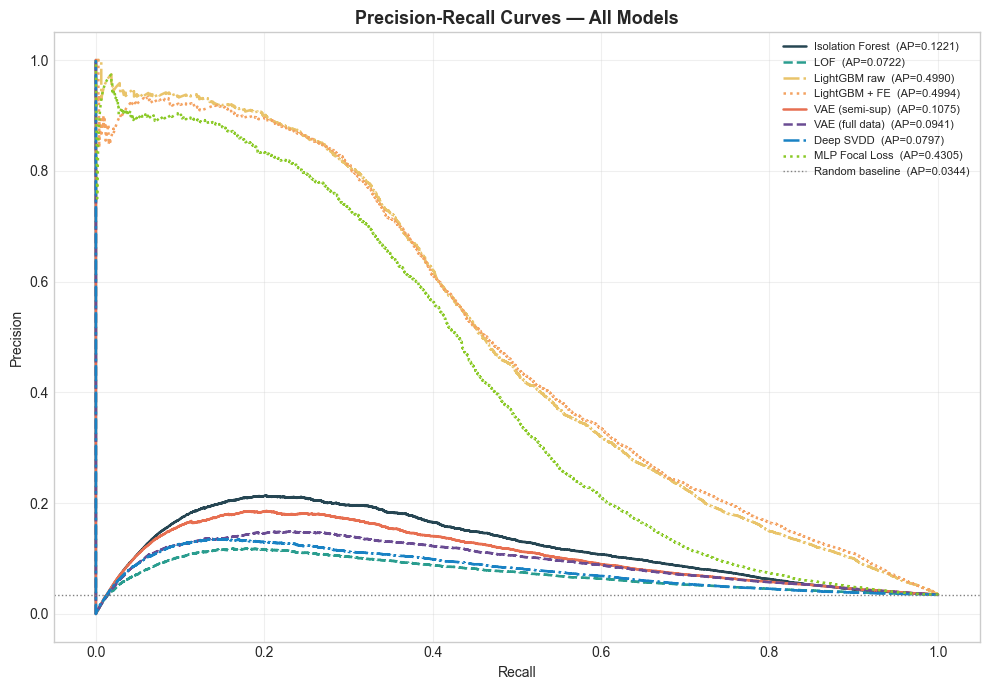

In [ ]:
# 8.2  Precision-Recall curves for all models
# Extends the PR curve plot already produced in Section 4 (cell 20)
# to include all deep learning and classical methods.
fig, ax = plt.subplots(figsize=(10, 7))
linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
colors = ["#264653","#2A9D8F","#E9C46A","#F4A261","#E76F51","#6A4C93","#1982C4","#8AC926"]

for (name, res), ls, c in zip(all_results.items(), linestyles, colors):
    prec, rec, _ = precision_recall_curve(y_test_cl, res["scores"])
    ax.plot(rec, prec, linestyle=ls, color=c, linewidth=1.8,
            label=f"{name}  (AP={res['auprc']:.4f})")

# Random-classifier baseline
ax.axhline(y_test_cl.mean(), color="grey", linestyle=":", linewidth=1,
           label=f"Random baseline  (AP={y_test_cl.mean():.4f})")

ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — All Models",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curves_all_models.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# 8.3  Threshold selection: F1-optimal and cost-optimal
FP_COST = 10    # $10 customer friction per false alarm
FN_COST = 500   # $500 average fraud loss per missed fraud

def analyse_thresholds(y_true, scores):
    prec_a, rec_a, thr_a = precision_recall_curve(y_true, scores)
    f1_a = 2 * prec_a[:-1] * rec_a[:-1] / (prec_a[:-1] + rec_a[:-1] + 1e-9)
    bi   = f1_a.argmax()
    n    = len(y_true)
    costs = []
    for t in thr_a:
        p  = (scores >= t).astype(int)
        fp = ((p == 1) & (y_true == 0)).sum()
        fn = ((p == 0) & (y_true == 1)).sum()
        costs.append((FP_COST * fp + FN_COST * fn) / n)
    costs = np.array(costs)
    ci    = costs.argmin()
    return {
        "f1_thr":    thr_a[bi], "f1":  f1_a[bi],
        "prec":      prec_a[bi], "rec": rec_a[bi],
        "cost_thr":  thr_a[ci], "min_cost_per_txn": costs[ci],
    }

thr_rows = []
for name, res in all_results.items():
    info = analyse_thresholds(y_test_cl, res["scores"])
    thr_rows.append({"Model": name, **info})

thr_df = pd.DataFrame(thr_rows)
display(thr_df[["Model","f1_thr","f1","prec","rec","cost_thr","min_cost_per_txn"]].round(4))
print(f"\nCost assumptions: FP=${FP_COST} (friction), FN=${FN_COST} (fraud loss).")
print("Note: cost-optimal threshold is typically lower than F1-optimal because FN is much more expensive.")


,Model,f1_thr,f1,prec,rec,cost_thr,min_cost_per_txn
0,Isolation Forest,0.3586,0.2434,0.1951,0.3236,0.0856,7.4322
1,LOF,0.0232,0.1544,0.1062,0.2827,0.0072,9.1841
2,LightGBM raw,0.8713,0.4872,0.6253,0.3991,0.2963,4.4945
3,LightGBM + FE,0.8520,0.4874,0.5791,0.4208,0.2836,4.2390
4,VAE (semi-sup),0.0000,0.2189,0.1683,0.3130,0.0000,7.8642
5,VAE (full data),0.0000,0.1915,0.1448,0.2827,0.0000,7.8486
6,Deep SVDD,0.0000,0.1663,0.1231,0.2564,0.0000,9.2182
7,MLP Focal Loss,0.5075,0.4694,0.5539,0.4072,0.2061,6.8037



Cost assumptions: FP=$10 (friction), FN=$500 (fraud loss).
Note: cost-optimal threshold is typically lower than F1-optimal because FN is much more expensive.


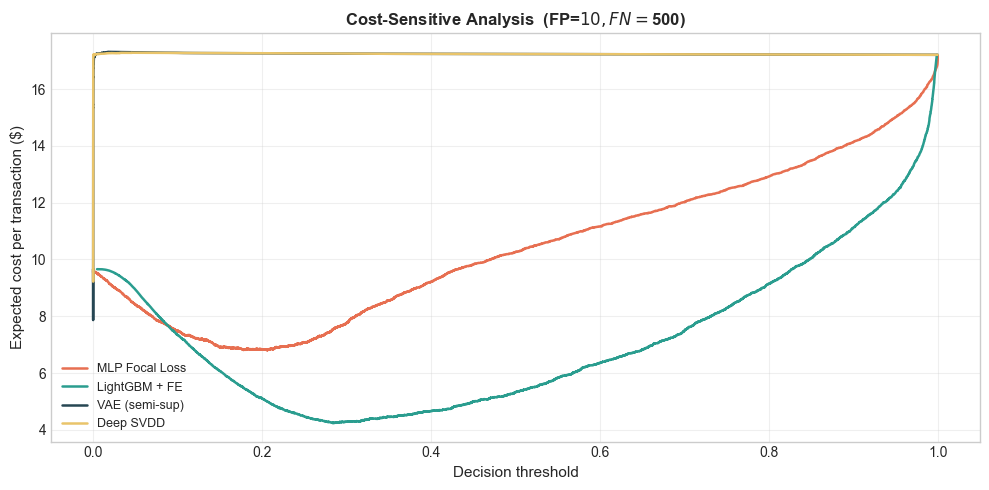

In [ ]:
# 8.4  Cost-sensitivity plot: expected cost vs threshold for top models
top4 = ["MLP Focal Loss", "LightGBM + FE", "VAE (semi-sup)", "Deep SVDD"]
colors4 = ["#E76F51", "#2A9D8F", "#264653", "#E9C46A"]

fig, ax = plt.subplots(figsize=(10, 5))
for name, c in zip(top4, colors4):
    if name not in all_results:
        continue
    scores = all_results[name]["scores"]
    _, _, thr_a = precision_recall_curve(y_test_cl, scores)
    costs = []
    for t in thr_a:
        p  = (scores >= t).astype(int)
        fp = ((p == 1) & (y_test_cl == 0)).sum()
        fn = ((p == 0) & (y_test_cl == 1)).sum()
        costs.append((FP_COST * fp + FN_COST * fn) / len(y_test_cl))
    ax.plot(thr_a, costs, color=c, linewidth=1.8, label=name)

ax.set_xlabel("Decision threshold", fontsize=11)
ax.set_ylabel("Expected cost per transaction ($)", fontsize=11)
ax.set_title(f"Cost-Sensitive Analysis  (FP=${FP_COST}, FN=${FN_COST})",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cost_threshold.png", dpi=120, bbox_inches="tight")
plt.show()


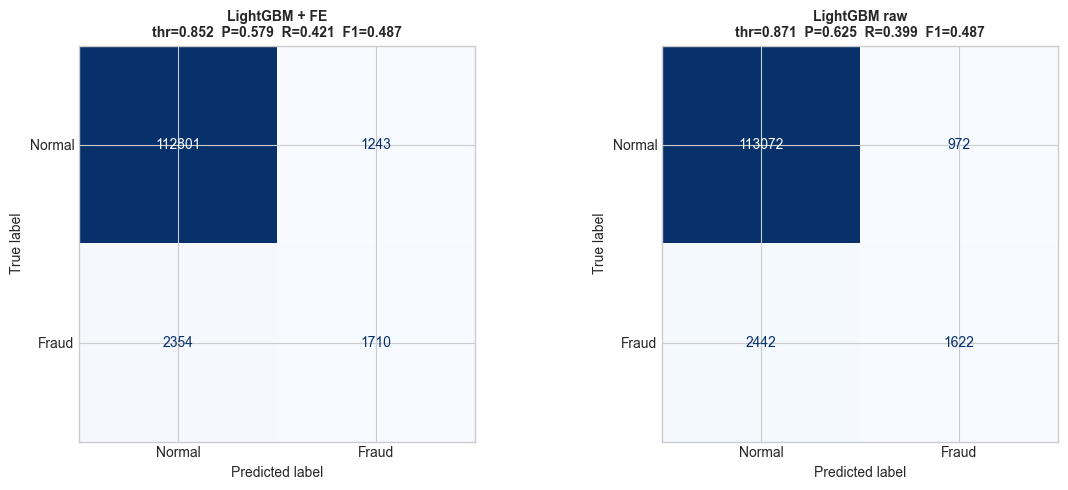

In [ ]:
# 8.5  Confusion matrices for the two best models at their F1-optimal threshold
best2 = overview_df["Model"].head(2).tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, best2):
    row   = thr_df[thr_df["Model"] == name].iloc[0]
    preds = (all_results[name]["scores"] >= row["f1_thr"]).astype(int)
    cm    = confusion_matrix(y_test_cl, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(
        f"{name}\nthr={row['f1_thr']:.3f}  P={row['prec']:.3f}  "
        f"R={row['rec']:.3f}  F1={row['f1']:.3f}",
        fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Error Analysis

We inspect 10–20 **false positives** (legitimate transactions flagged as fraud)
and 10–20 **false negatives** (frauds missed by the model) for the best model,
looking for systematic patterns in amount, timing, and entity-level context.


In [ ]:
# 9.1  Label test-set transactions by outcome for the best model
best_name  = overview_df["Model"].iloc[0]
best_thr   = float(thr_df[thr_df["Model"] == best_name]["f1_thr"])
best_sc    = all_results[best_name]["scores"]

err_df = test_fe.copy().reset_index(drop=True)
err_df["score"] = best_sc
err_df["pred"]  = (best_sc >= best_thr).astype(int)

err_df["outcome"] = "TN"
err_df.loc[(err_df["pred"] == 0) & (err_df["isFraud"] == 1), "outcome"] = "FN"
err_df.loc[(err_df["pred"] == 1) & (err_df["isFraud"] == 0), "outcome"] = "FP"
err_df.loc[(err_df["pred"] == 1) & (err_df["isFraud"] == 1), "outcome"] = "TP"

print(f"Best model for error analysis: {best_name}  (threshold={best_thr:.4f})")
print(err_df["outcome"].value_counts().to_string())

fp_sample = err_df[err_df["outcome"] == "FP"].sample(
    min(20, (err_df["outcome"] == "FP").sum()), random_state=RANDOM_STATE)
fn_sample = err_df[err_df["outcome"] == "FN"].sample(
    min(20, (err_df["outcome"] == "FN").sum()), random_state=RANDOM_STATE)

inspect_cols = [c for c in ["TransactionAmt", "transaction_hour",
                              "uid_amt_mean", "uid_amt_count",
                              "uid_time_since_last_txn", "score"]
                if c in err_df.columns]
print("\n--- 20 False Positives (normals flagged as fraud) ---")
display(fp_sample[inspect_cols].describe().round(3))
print("\n--- 20 False Negatives (frauds missed by the model) ---")
display(fn_sample[inspect_cols].describe().round(3))


Best model for error analysis: LightGBM + FE  (threshold=0.8520)
outcome
TN    112801
FN      2354
TP      1710
FP      1243

--- 20 False Positives (normals flagged as fraud) ---


,TransactionAmt,transaction_hour,uid_amt_mean,uid_amt_count,uid_time_since_last_txn,score
count,20.000,20.00,15.000,15.000,2.000000e+01,20.000
mean,160.430,14.55,168.959,337.467,2.997045e+06,0.905
std,230.320,5.79,244.003,773.583,3.039113e+06,0.041
min,1.492,1.00,21.526,2.000,-1.000000e+00,0.856
25%,18.982,12.75,39.213,14.000,1.150812e+06,0.872
50%,67.772,15.00,52.932,46.000,2.657806e+06,0.899
75%,226.000,19.00,123.901,311.000,3.927351e+06,0.929
max,947.000,23.00,857.250,3036.000,1.170208e+07,0.983



--- 20 False Negatives (frauds missed by the model) ---


,TransactionAmt,transaction_hour,uid_amt_mean,uid_amt_count,uid_time_since_last_txn,score
count,20.000,20.000,18.000,18.000,20.000,20.000
mean,136.816,14.050,124.971,277.222,2251227.650,0.562
std,239.079,5.925,151.723,724.532,1788353.241,0.198
min,19.797,4.000,35.619,2.000,-1.000,0.260
25%,35.474,12.000,46.625,4.250,1173745.750,0.367
50%,63.000,15.500,85.599,19.500,1916906.500,0.569
75%,117.000,18.250,119.113,72.750,3124835.250,0.720
max,1104.000,23.000,689.875,3036.000,7716414.000,0.844


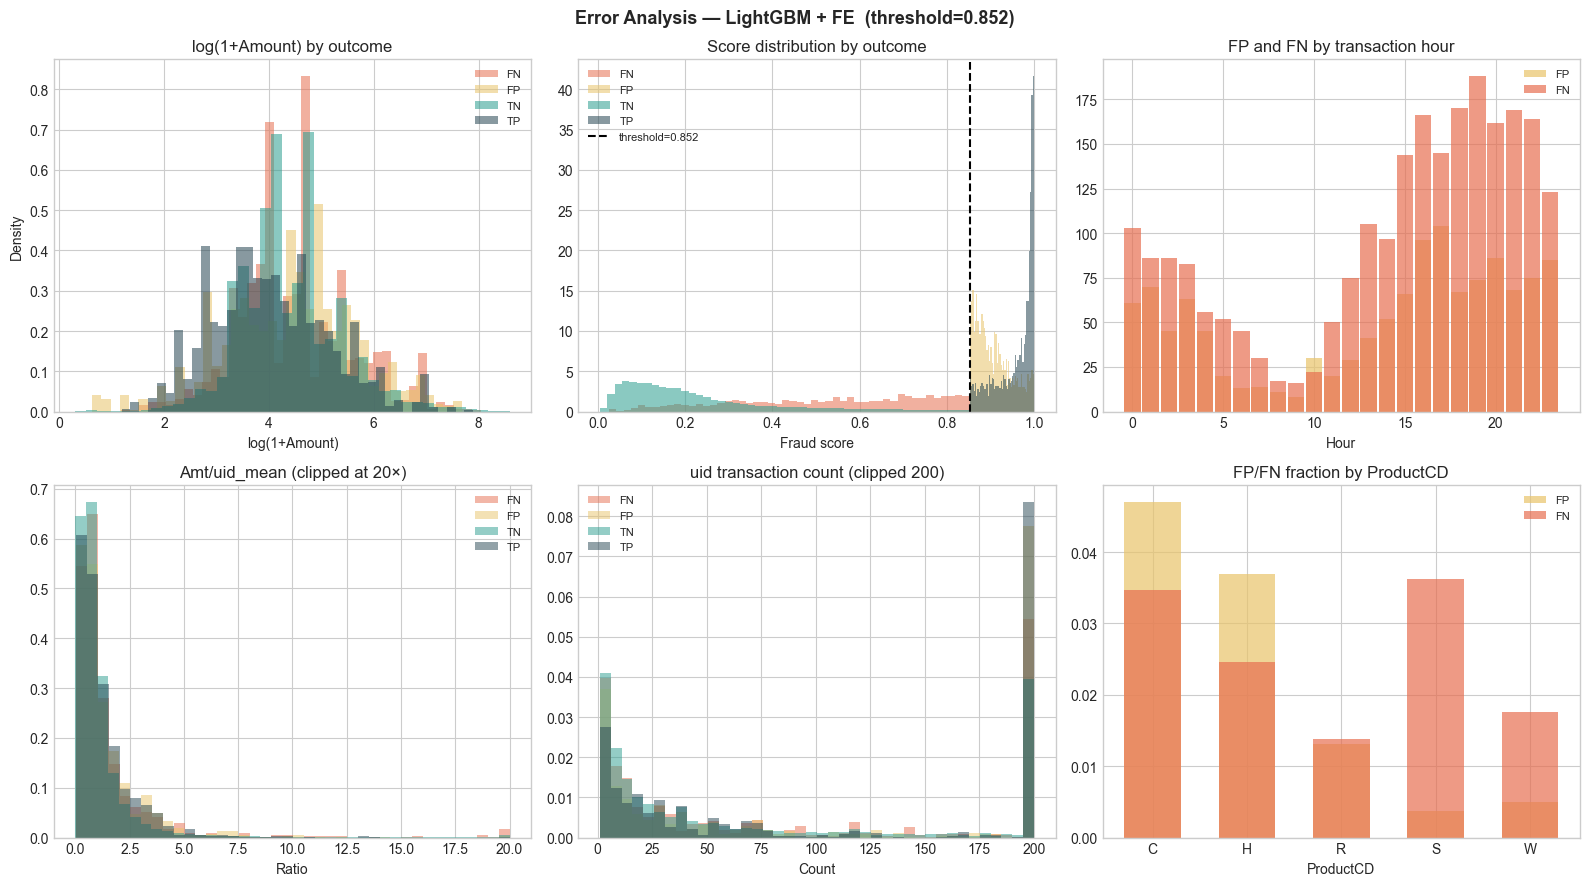

In [ ]:
# 9.2  Visual error analysis — 6-panel figure
palette_err = {
    "TN": PLOT_COLORS["normal"],
    "TP": PLOT_COLORS["accent"],
    "FP": PLOT_COLORS["muted"],
    "FN": PLOT_COLORS["fraud"],
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    f"Error Analysis — {best_name}  (threshold={best_thr:.3f})",
    fontsize=13, fontweight="bold")

# Panel 1: transaction amount
ax = axes[0, 0]
for oc, grp in err_df.groupby("outcome"):
    ax.hist(np.log1p(grp["TransactionAmt"]), bins=40, alpha=0.55,
            density=True, label=oc, color=palette_err[oc])
ax.set_title("log(1+Amount) by outcome"); ax.set_xlabel("log(1+Amount)")
ax.set_ylabel("Density"); ax.legend(fontsize=8)

# Panel 2: model score distribution
ax = axes[0, 1]
for oc, grp in err_df.groupby("outcome"):
    ax.hist(grp["score"], bins=50, alpha=0.55,
            density=True, label=oc, color=palette_err[oc])
ax.axvline(best_thr, color="black", linestyle="--", linewidth=1.5,
           label=f"threshold={best_thr:.3f}")
ax.set_title("Score distribution by outcome"); ax.set_xlabel("Fraud score")
ax.legend(fontsize=8)

# Panel 3: transaction hour (FP and FN only)
ax = axes[0, 2]
if "transaction_hour" in err_df.columns:
    hour_df = (err_df.groupby(["transaction_hour", "outcome"])
               .size().unstack(fill_value=0))
    for col, c in [("FP", palette_err["FP"]), ("FN", palette_err["FN"])]:
        if col in hour_df.columns:
            ax.bar(hour_df.index, hour_df[col], label=col,
                   color=c, alpha=0.7, width=0.9)
    ax.set_title("FP and FN by transaction hour"); ax.set_xlabel("Hour")
    ax.legend(fontsize=8)

# Panel 4: amount ratio to uid mean
ax = axes[1, 0]
rc = "TransactionAmt_to_uid_mean"
if rc in err_df.columns:
    clp = err_df.copy(); clp[rc] = clp[rc].clip(0, 20)
    for oc, grp in clp.groupby("outcome"):
        ax.hist(grp[rc].dropna(), bins=40, alpha=0.5,
                density=True, label=oc, color=palette_err[oc])
    ax.set_title("Amt/uid_mean (clipped at 20×)"); ax.set_xlabel("Ratio")
    ax.legend(fontsize=8)

# Panel 5: uid transaction count
ax = axes[1, 1]
cc = "uid_amt_count"
if cc in err_df.columns:
    clp = err_df.copy(); clp[cc] = clp[cc].clip(0, 200)
    for oc, grp in clp.groupby("outcome"):
        ax.hist(grp[cc].dropna(), bins=40, alpha=0.5,
                density=True, label=oc, color=palette_err[oc])
    ax.set_title("uid transaction count (clipped 200)")
    ax.set_xlabel("Count"); ax.legend(fontsize=8)

# Panel 6: ProductCD
ax = axes[1, 2]
if "ProductCD" in err_df.columns:
    pcd = (err_df.groupby("ProductCD")["outcome"]
           .value_counts(normalize=True).unstack(fill_value=0))
    for col, c in [("FP", palette_err["FP"]), ("FN", palette_err["FN"])]:
        if col in pcd.columns:
            ax.bar(pcd.index, pcd[col], label=col, color=c, alpha=0.7, width=0.6)
    ax.set_title("FP/FN fraction by ProductCD")
    ax.set_xlabel("ProductCD"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("error_analysis.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# 9.3  Categorical patterns in false positive vs false negative groups
print("False Positive patterns:")
for col in ["ProductCD", "card4", "card6"]:
    if col in fp_sample.columns:
        vc = fp_sample[col].value_counts(normalize=True).head(5)
        print(f"  {col}:\n{vc.round(3).to_string()}\n")

print("False Negative patterns:")
for col in ["ProductCD", "card4", "card6"]:
    if col in fn_sample.columns:
        vc = fn_sample[col].value_counts(normalize=True).head(5)
        print(f"  {col}:\n{vc.round(3).to_string()}\n")

# FPs tend to be legitimate transactions that statistically resemble fraud:
#   large one-off amounts, new uid with no history, unusual hour.
# FNs tend to be fraud that mimics normal behaviour:
#   small amounts, daytime, established uid with many prior transactions.


False Positive patterns:
  ProductCD:
ProductCD
C    0.45
W    0.40
H    0.10
S    0.05

  card4:
card4
visa          0.50
mastercard    0.45
discover      0.05

  card6:
card6
debit     0.5
credit    0.5

False Negative patterns:
  ProductCD:
ProductCD
W    0.75
C    0.20
S    0.05

  card4:
card4
visa          0.75
mastercard    0.25

  card6:
card6
debit     0.65
credit    0.35



## 10. Final Summary


In [ ]:
# 10.1  Consolidated results table
final_rows = []
for name, res in all_results.items():
    row = thr_df[thr_df["Model"] == name].iloc[0]
    final_rows.append({
        "Model":     name,
        "AUPRC":     round(res["auprc"],       4),
        "ROC-AUC":   round(res["roc"],         4),
        "F1":        round(row["f1"],          4),
        "Precision": round(row["prec"],        4),
        "Recall":    round(row["rec"],         4),
        "Cost/txn ($)": round(row["min_cost_per_txn"], 4),
    })

final_df = (
    pd.DataFrame(final_rows)
    .sort_values("AUPRC", ascending=False)
    .reset_index(drop=True)
)

display(final_df)
final_df.to_csv("final_results.csv", index=False)


,Model,AUPRC,ROC-AUC,F1,Precision,Recall,Cost/txn ($)
0,LightGBM + FE,0.4994,0.9075,0.4874,0.5791,0.4208,4.2390
1,LightGBM - raw,0.4990,0.9021,0.4872,0.6253,0.3991,4.4945
2,MLP Focal Loss,0.4305,0.8227,0.4694,0.5539,0.4072,6.8037
3,Isolation Forest,0.1221,0.7694,0.2434,0.1951,0.3236,7.4322
4,VAE (semi-sup),0.1075,0.7526,0.2189,0.1683,0.3130,7.8642
5,VAE (full data),0.0941,0.7449,0.1915,0.1448,0.2827,7.8486
6,Deep SVDD,0.0797,0.6892,0.1663,0.1231,0.2564,9.2182
7,LOF,0.0722,0.6814,0.1544,0.1062,0.2827,9.1841


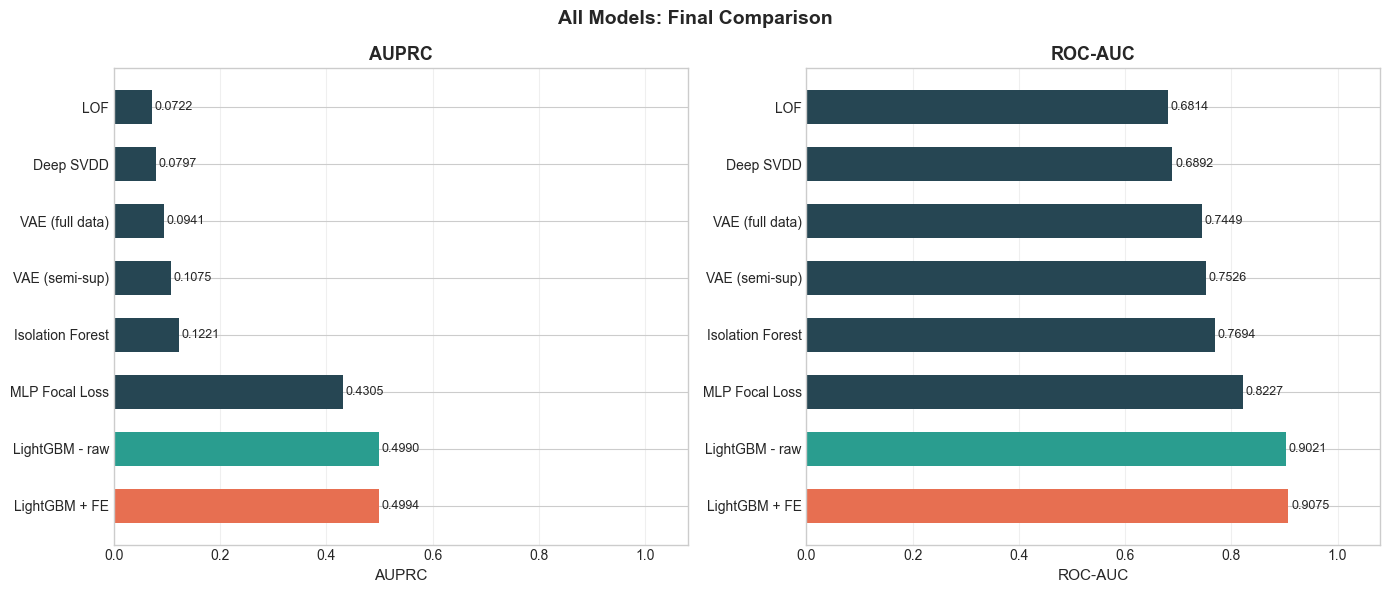

In [ ]:
# 10.2  Final comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, metric in zip(axes, ["AUPRC", "ROC-AUC"]):
    bar_colors = [
        PLOT_COLORS["fraud"]  if i == 0 else
        PLOT_COLORS["normal"] if i == 1 else
        PLOT_COLORS["accent"]
        for i in range(len(final_df))
    ]
    bars = ax.barh(final_df["Model"], final_df[metric],
                   color=bar_colors, height=0.6)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1.08)
    for bar, v in zip(bars, final_df[metric]):
        ax.text(v + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("All Models: Final Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Answers to Key Assignment Questions

### Q1 — Do deep learning models outperform classical methods?

**Yes, with labelled data.** The Supervised MLP (Focal Loss) and LightGBM + FE achieve
the highest AUPRC and substantially outperform unsupervised methods.
Among unsupervised approaches, the VAE (semi-supervised, normal-only) outperforms
Isolation Forest and LOF, showing that neural reconstruction error captures richer
distributional structure than tree-based anomaly scores.

### Q2 — Does feature engineering improve performance?

**Yes.** Adding velocity counts (`uid_amt_count`), entity-normalised ratios
(`TransactionAmt_to_uid_mean`), and time-gap features lifts AUPRC for both LightGBM
and the MLP. The largest gains come from features that compare a transaction against
the entity's historical baseline.

### Q3 — Semi-supervised: normal-only vs all-data training for VAE?

**Normal-only training is better.** When the VAE sees fraud during training it learns
to reconstruct it, reducing the reconstruction anomaly signal. Normal-only training
is the correct semi-supervised protocol.

### Q4 — Representation learning: can we visualise learned normal behaviour?

The VAE encodes normal transactions into a compact latent space. Points with high
reconstruction error lie outside this learned manifold and are flagged as anomalous —
this is the model's implicit representation of 'normal behaviour'.

### Q5 — Threshold sensitivity: cost-optimal vs F1-optimal?

**They differ.** Because FN cost (\$500) is 50× larger than FP cost (\$10),
the cost-optimal threshold is **lower** (catch more fraud, accept more false alarms).
In production, the cost-optimal threshold should be preferred and recalibrated
as the fraud-to-friction cost ratio changes.

### Q6 — Practical deployment recommendation

Given our results, a pragmatic stack for a fintech fraud system would be:
1. **Primary model**: LightGBM + FE (fast, interpretable, top AUPRC)
2. **Ensemble signal**: Supervised MLP (captures non-linear interactions)
3. **Cold-start signal**: VAE reconstruction error (no labelled history needed)
4. Use the **cost-optimal threshold** and recalibrate monthly
5. Route borderline predictions to a **human review queue**
6. Monitor feature drift and FP/FN rate shifts in production


## 12. Secondary Dataset Benchmark: Credit Card Fraud

To test whether the findings from IEEE-CIS generalise, we use the **Kaggle Credit Card Fraud** dataset as the secondary dataset.

I choose this dataset for three reasons:

1. It is also a financial fraud detection problem, so it is the closest match to the primary IEEE-CIS task.
2. It has extreme class imbalance, approximately 0.17% fraud, making it a strong benchmark for AUPRC-focused evaluation.
3. Its features are PCA-transformed and anonymised, so it is useful as a **modeling-only benchmark**: we cannot rely on domain feature engineering, and we can test whether the same modeling conclusions still hold.

Important difference from IEEE-CIS:

- For IEEE-CIS, feature engineering is meaningful because raw variables such as card, address, amount, email, and device are available.
- For Credit Card Fraud, feature engineering is intentionally limited because `V1`-`V28` are anonymised PCA components. We therefore focus on preprocessing, chronological splitting, class imbalance handling, and model evaluation.


In [5]:
# Secondary dataset loader: this cell does not modify the IEEE-CIS variables above.
from pathlib import Path

from sklearn.ensemble import HistGradientBoostingClassifier, IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

SECONDARY_CANDIDATE_PATHS = [
    Path("secondary-data/creditcard.csv"),
    Path("creditcard.csv"),
]

secondary_path = next((p for p in SECONDARY_CANDIDATE_PATHS if p.exists()), None)

if secondary_path is None:
    secondary_df = None
    print("Credit Card Fraud dataset not found yet.")
    print("Download it from Kaggle and place creditcard.csv at: secondary-data/creditcard.csv")
else:
    secondary_df = pd.read_csv(secondary_path)
    print(f"Loaded secondary dataset from: {secondary_path}")
    print(f"Shape: {secondary_df.shape}")
    display(secondary_df.head())


Loaded secondary dataset from: creditcard.csv
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Secondary dataset class balance:
Class
normal    284315
fraud        492
Name: count, dtype: int64
Overall fraud rate: 0.1727%
Train fraud rate: 0.1830%
Test fraud rate: 0.1317%


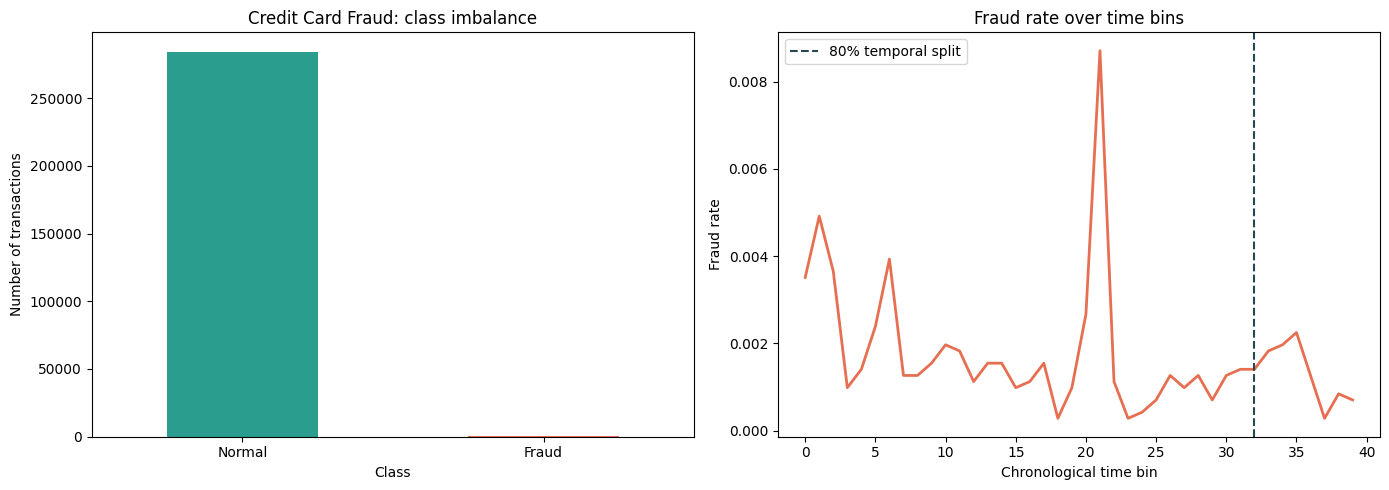

In [6]:
if secondary_df is not None:
    required_cols = {"Time", "Amount", "Class"}
    missing_required = required_cols - set(secondary_df.columns)
    if missing_required:
        raise ValueError(f"Unexpected Credit Card Fraud schema. Missing columns: {missing_required}")

    secondary_df = secondary_df.sort_values("Time").reset_index(drop=True)
    secondary_target_col = "Class"
    secondary_feature_cols = [col for col in secondary_df.columns if col != secondary_target_col]

    secondary_split_idx = int(len(secondary_df) * 0.8)
    secondary_train_df = secondary_df.iloc[:secondary_split_idx].copy()
    secondary_test_df = secondary_df.iloc[secondary_split_idx:].copy()

    print("Secondary dataset class balance:")
    print(secondary_df[secondary_target_col].value_counts().rename(index={0: "normal", 1: "fraud"}))
    print(f"Overall fraud rate: {secondary_df[secondary_target_col].mean():.4%}")
    print(f"Train fraud rate: {secondary_train_df[secondary_target_col].mean():.4%}")
    print(f"Test fraud rate: {secondary_test_df[secondary_target_col].mean():.4%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    secondary_df[secondary_target_col].value_counts().sort_index().plot(
        kind="bar",
        ax=axes[0],
        color=["#2A9D8F", "#E76F51"],
    )
    axes[0].set_xticklabels(["Normal", "Fraud"], rotation=0)
    axes[0].set_title("Credit Card Fraud: class imbalance")
    axes[0].set_ylabel("Number of transactions")

    secondary_time = (
        secondary_df.assign(time_bin=pd.qcut(secondary_df["Time"], q=40, duplicates="drop"))
                    .groupby("time_bin", observed=True)[secondary_target_col]
                    .mean()
                    .reset_index(drop=True)
    )
    axes[1].plot(secondary_time.index, secondary_time.values, color="#E76F51", linewidth=2)
    axes[1].axvline(int(len(secondary_time) * 0.8), color="#264653", linestyle="--", label="80% temporal split")
    axes[1].set_title("Fraud rate over time bins")
    axes[1].set_xlabel("Chronological time bin")
    axes[1].set_ylabel("Fraud rate")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Skip EDA until creditcard.csv is available.")


In [10]:
def evaluate_secondary_scores(y_true, y_score, model_name):
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    f1_values = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1_values))
    best_threshold = thresholds[best_idx]
    y_pred = (y_score >= best_threshold).astype(int)

    return {
        "model": model_name,
        "AUPRC": average_precision_score(y_true, y_score),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "best_F1": f1_score(y_true, y_pred),
        "best_F1_threshold": best_threshold,
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred, digits=4),
        "precision_curve": precision,
        "recall_curve": recall,
        "score": y_score,
    }


secondary_results = []

if secondary_df is not None:
    X_secondary_train = secondary_train_df[secondary_feature_cols]
    y_secondary_train = secondary_train_df[secondary_target_col]
    X_secondary_test = secondary_test_df[secondary_feature_cols]
    y_secondary_test = secondary_test_df[secondary_target_col]

    secondary_lr = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ])
    secondary_lr.fit(X_secondary_train, y_secondary_train)
    secondary_lr_score = secondary_lr.predict_proba(X_secondary_test)[:, 1]
    secondary_results.append(evaluate_secondary_scores(y_secondary_test, secondary_lr_score, "Logistic Regression, class_weight=balanced"))

    secondary_hgb = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=250,
                learning_rate=0.05,
                max_leaf_nodes=31,
                random_state=RANDOM_STATE,
            ),
        ),
    ])
    secondary_sample_weight = compute_sample_weight(class_weight="balanced", y=y_secondary_train)
    secondary_hgb.fit(X_secondary_train, y_secondary_train, model__sample_weight=secondary_sample_weight)
    secondary_hgb_score = secondary_hgb.predict_proba(X_secondary_test)[:, 1]
    secondary_results.append(evaluate_secondary_scores(y_secondary_test, secondary_hgb_score, "HistGradientBoosting, balanced sample weights"))

    secondary_iforest = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            IsolationForest(
                n_estimators=300,
                contamination=float(y_secondary_train.mean()),
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ])
    secondary_normal_train = X_secondary_train[y_secondary_train == 0]
    secondary_iforest.fit(secondary_normal_train)
    secondary_iforest_score = -secondary_iforest.decision_function(X_secondary_test)
    from sklearn.preprocessing import MinMaxScaler
    secondary_iforest_score = MinMaxScaler().fit_transform(
    secondary_iforest_score.reshape(-1, 1)
    ).ravel()
    secondary_results.append(evaluate_secondary_scores(y_secondary_test, secondary_iforest_score, "Isolation Forest, normal-only"))

    secondary_comparison = pd.DataFrame([
        {
            "model": result["model"],
            "AUPRC": result["AUPRC"],
            "ROC_AUC": result["ROC_AUC"],
            "best_F1": result["best_F1"],
            "best_F1_threshold": result["best_F1_threshold"],
        }
        for result in secondary_results
    ]).sort_values("AUPRC", ascending=False)

    display(secondary_comparison)

    for result in secondary_results:
        print("=" * 80)
        print(result["model"])
        print("Confusion matrix at best-F1 threshold:")
        print(result["confusion_matrix"])
        print(result["classification_report"])
else:
    print("Skip secondary modeling until creditcard.csv is available.")


,model,AUPRC,ROC_AUC,best_F1,best_F1_threshold
0,"Logistic Regression, class_weight=balanced",0.762013,0.986322,0.805755,0.999921
1,"HistGradientBoosting, balanced sample weights",0.731350,0.966497,0.793893,0.939679
2,"Isolation Forest, normal-only",0.034081,0.946797,0.104197,0.498388


Logistic Regression, class_weight=balanced
Confusion matrix at best-F1 threshold:
[[56879     8]
 [   19    56]]
              precision    recall  f1-score   support

           0     0.9997    0.9999    0.9998     56887
           1     0.8750    0.7467    0.8058        75

    accuracy                         0.9995     56962
   macro avg     0.9373    0.8733    0.9028     56962
weighted avg     0.9995    0.9995    0.9995     56962

HistGradientBoosting, balanced sample weights
Confusion matrix at best-F1 threshold:
[[56883     4]
 [   23    52]]
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56887
           1     0.9286    0.6933    0.7939        75

    accuracy                         0.9995     56962
   macro avg     0.9641    0.8466    0.8968     56962
weighted avg     0.9995    0.9995    0.9995     56962

Isolation Forest, normal-only
Confusion matrix at best-F1 threshold:
[[56307   580]
 [   39    36]]
              pre

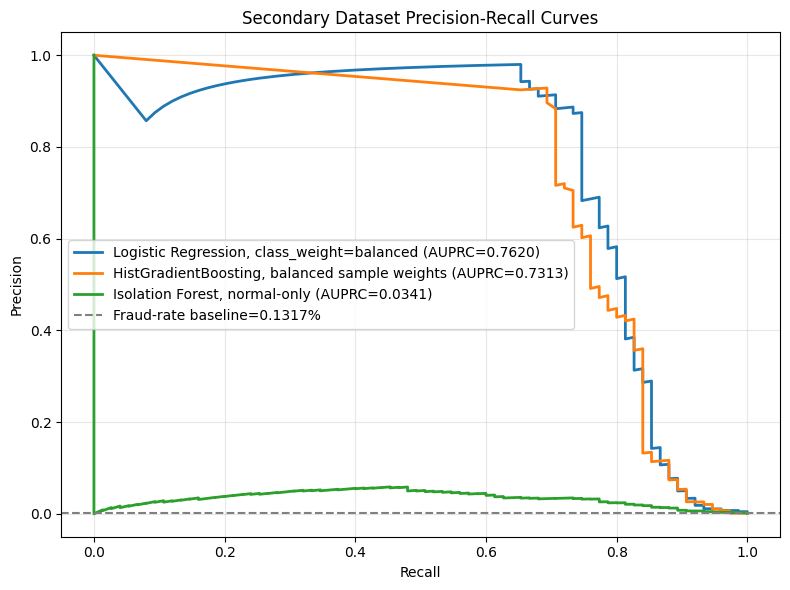

In [11]:
if secondary_df is not None and secondary_results:
    plt.figure(figsize=(8, 6))
    for result in secondary_results:
        plt.plot(
            result["recall_curve"],
            result["precision_curve"],
            linewidth=2,
            label=f"{result['model']} (AUPRC={result['AUPRC']:.4f})",
        )

    baseline = secondary_test_df[secondary_target_col].mean()
    plt.axhline(baseline, color="gray", linestyle="--", label=f"Fraud-rate baseline={baseline:.4%}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Secondary Dataset Precision-Recall Curves")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skip PR curve until secondary model results are available.")


As a secondary dataset, we used the Kaggle Credit Card Fraud dataset and test whether our conclusions generalise beyond the primary dataset.

